# Analisis Predictivo de Churn — Concesionario de Automoviles

**Objetivo:** Desarrollar un modelo de Machine Learning para predecir la fuga de clientes
del servicio de taller oficial, permitiendo implementar estrategias de retencion proactivas.

---

### Estructura del Notebook

**FASE 1: Exploracion y Preparacion de Datos**
1. Configuracion, importaciones y carga de datos
2. Analisis general del dataset
3. Analisis de churn (variable objetivo)
4. Perfil del cliente: churner vs no-churner
5. Analisis de revisiones y taller
6. Analisis economico (margenes y costes)
7. Correlaciones entre variables
8. Conclusiones previas al modelo + DataMart

**FASE 2: Modelado ML — Evolucion en 4 Enfoques**
- Enfoque 1: Baseline (Random Forest + XGBoost)
- Enfoque 2: Modelo de retencion (filtrado)
- Enfoque 3: Feature Engineering (`nunca_ha_venido`)
- **Enfoque 4: Eliminacion del leakage logico (modelo final)**

**FASE 3: Prediccion sobre Datos Fresh**
- Aplicacion del modelo final a 10,000 nuevos clientes

---

**Dataset:** 58,049 registros historicos (2018-2023) | 44,053 clientes unicos | 11 modelos

## 1. Configuracion, Importaciones y Carga de Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Estilo global de los gráficos
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style("whitegrid")
COLORES = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6', '#1abc9c']

print("✅ Librerías cargadas correctamente")

# Instalar librerias de ML si no estan disponibles
import subprocess
import sys

for lib in ['xgboost', 'lightgbm']:
    try:
        __import__(lib)
        print('OK: ' + lib + ' ya esta instalado')
    except ImportError:
        print('Instalando ' + lib + '...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', lib, '-q'])
        print('OK: ' + lib + ' instalado')



# ─── CONFIGURACIÓN ────────────────────────────────────────────────
USAR_NUBE = True  # True = histórico desde nube, False = todo local
# ──────────────────────────────────────────────────────────────────

print(" Cargando datos...")

if USAR_NUBE:
    # HISTÓRICO desde la nube
    URL_HISTORICO = "https://storage.googleapis.com/jvelare-public/bq-results-20260211-093843-1770799837095"
    df_historico = pd.read_csv(URL_HISTORICO)
    print(f"   ✅ Histórico (nube): {len(df_historico):,} filas")
    
    # COSTES desde local (archivo que ya tienes)
    dim_costes = pd.DataFrame({
        'Modelo': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K'],
        'Margen': [28.0, 33.0, 33.0, 33.0, 37.0, 42.0, 42.0, 42.0, 43.0, 5.0, 5.0],
        'Costetransporte': [250.0] * 11,
        'Margendistribuidor': [5.0] * 11,
        'GastosMarketing': [5.0, 5.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 5.0, 25.0, 25.0],
        'Mantenimiento_medio': [250.0, 263.0, 276.0, 290.0, 305.0, 320.0, 336.0, 353.0, 371.0, 390.0, 410.0],
        'Comisión_Marca': [2.0, 2.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 8.0, 8.0, 8.0]
    })
    print(f"   ✅ Costes (local):   {len(dim_costes):,} modelos")
    
    # NUEVOS CLIENTES desde local
    nuevos = pd.read_csv('./Data/DataLake/nuevos_clientes.csv')
    print(f"   ✅ Nuevos clientes:  {len(nuevos):,} filas")

else:
    # TODO LOCAL
    df_historico = pd.read_csv('./datawarehouse/historico_limpio.csv')
    dim_costes = pd.read_csv('./datawarehouse/dim_costes.csv')
    nuevos = pd.read_csv('./datawarehouse/nuevos_clientes_limpios.csv')
    print("   ✅ Todo cargado desde archivos locales")

# ══════════════════════════════════════════════════════════════════
# LIMPIEZA Y CREACIÓN DE TABLAS DEL DW (en memoria)
# ══════════════════════════════════════════════════════════════════

# 1. CREAR CHURN_BIN (numérico)
df_historico['Churn_bin'] = (df_historico['Churn_400'] == 'Y').astype(int)

# 2. CREAR FLAG_SIN_REVISION
df_historico['FLAG_SIN_REVISION'] = (df_historico['DAYS_LAST_SERVICE'].isna()).astype(int)

# 3. FACT_VENTAS
columnas_venta = ['CODE', 'Customer_ID', 'Id_Producto', 'Sales_Date', 'PVP',
                  'MOTIVO_VENTA', 'FORMA_PAGO', 'COSTE_VENTA_NO_IMPUESTOS',
                  'Lead_compra', 'Fue_Lead', 'Origen', 'Margen_eur_bruto',
                  'Margen_eur', 'ENCUESTA_CLIENTE_ZONA_TALLER',
                  'Churn_400', 'Churn_bin']
fact_ventas = df_historico[columnas_venta].copy()
fact_ventas['Margen_pct'] = (fact_ventas['Margen_eur'] / fact_ventas['PVP'] * 100).round(2)
fact_ventas['FLAG_Margen_Negativo'] = (fact_ventas['Margen_eur'] < 0).astype(int)

# 4. FACT_REVISIONES
columnas_revision = ['CODE', 'Customer_ID', 'Revisiones', 'Km_medio_por_revision',
                     'km_ultima_revision', 'DAYS_LAST_SERVICE', 'QUEJA',
                     'Churn_400', 'Churn_bin', 'FLAG_SIN_REVISION']
fact_revisiones = df_historico[columnas_revision].copy()

# 5. DIM_CLIENTES (único por Customer_ID)
columnas_cliente = ['Customer_ID', 'GENERO', 'Edad', 'CODIGO_POSTAL',
                    'RENTA_MEDIA_ESTIMADA', 'STATUS_SOCIAL', 'ZONA',
                    'PROV_DESC', 'TIENDA_DESC']
dim_clientes = df_historico[columnas_cliente + ['Sales_Date']].sort_values('Sales_Date', ascending=False)
dim_clientes = dim_clientes.drop_duplicates(subset='Customer_ID', keep='first')
dim_clientes = dim_clientes.drop(columns='Sales_Date').reset_index(drop=True)

# 6. DIM_VEHICULOS (ahora incluye garantia y mantenimiento)
columnas_vehiculo = ['CODE', 'Id_Producto', 'Modelo', 'TIPO_CARROCERIA', 'Fuel',
                     'TRANSMISION_ID', 'Equipamiento', 'Kw',
                     'EXTENSION_GARANTIA', 'EN_GARANTIA', 'MANTENIMIENTO_GRATUITO',
                     'SEGURO_BATERIA_LARGO_PLAZO']
dim_vehiculos = df_historico[columnas_vehiculo].drop_duplicates(subset='CODE').reset_index(drop=True)

# 7. DIM_COSTES (agregar columnas calculadas)
dim_costes['Alpha'] = dim_costes['Modelo'].apply(lambda m: 0.07 if m in ['A','B'] else 0.10)
dim_costes['Categoria_Precio'] = dim_costes['Modelo'].apply(
    lambda m: 'PREMIUM' if m in ['A','B'] else 'ESTANDAR'
)

# ══════════════════════════════════════════════════════════════════
# CREAR TABLA MAESTRA (unir todo)
# ══════════════════════════════════════════════════════════════════

df = fact_ventas.merge(
    fact_revisiones[['CODE','Revisiones','Km_medio_por_revision',
                     'km_ultima_revision','DAYS_LAST_SERVICE',
                     'FLAG_SIN_REVISION','QUEJA']],
    on='CODE', how='left'
)

df = df.merge(dim_clientes, on='Customer_ID', how='left')

df = df.merge(
    dim_vehiculos[['CODE','Modelo','Fuel','Kw','Equipamiento','TIPO_CARROCERIA',
                   'TRANSMISION_ID','EXTENSION_GARANTIA','EN_GARANTIA','MANTENIMIENTO_GRATUITO',
                   'SEGURO_BATERIA_LARGO_PLAZO']], 
    on='CODE', how='left'
)

df = df.merge(
    dim_costes[['Modelo','Mantenimiento_medio','Alpha','Categoria_Precio']], 
    on='Modelo', how='left'
)

# Convertir fechas a formato correcto
df['Sales_Date'] = pd.to_datetime(df['Sales_Date'], format='%d/%m/%Y', errors='coerce')

# ══════════════════════════════════════════════════════════════════
# LIMPIEZA DE VARIABLES NUEVAS
# ══════════════════════════════════════════════════════════════════

# QUEJA: nulos → "NO" (si no hay registro de queja = no se quejó), luego a binario
df['QUEJA'] = df['QUEJA'].fillna('NO')
df['tiene_queja'] = (df['QUEJA'].str.upper().str.strip() == 'SI').astype(int)

# EXTENSION_GARANTIA: convertir a binario (contiene "SI" → 1, resto → 0)
df['extension_garantia_bin'] = df['EXTENSION_GARANTIA'].fillna('NO').str.upper().str.contains('SI').astype(int)

# EN_GARANTIA: convertir a binario
df['en_garantia_bin'] = (df['EN_GARANTIA'].fillna('NO').str.upper().str.strip() == 'SI').astype(int)

print(f"\n{'='*60}")
print(f"✅ TABLA MAESTRA CREADA")
print(f"{'='*60}")
print(f"   Filas:           {len(df):,}")
print(f"   Columnas:        {len(df.columns)}")
print(f"   Clientes únicos: {df['Customer_ID'].nunique():,}")
print(f"   Periodo:         {df['Sales_Date'].min().strftime('%d/%m/%Y')} → {df['Sales_Date'].max().strftime('%d/%m/%Y')}")
print(f"   Tasa de Churn:   {df['Churn_bin'].mean()*100:.1f}%")
print()
print("Variables nuevas añadidas:")
print(f"   tiene_queja:           {df['tiene_queja'].sum():,} clientes con queja ({df['tiene_queja'].mean()*100:.1f}%)")
print(f"   extension_garantia_bin: {df['extension_garantia_bin'].sum():,} con extensión ({df['extension_garantia_bin'].mean()*100:.1f}%)")
print(f"   en_garantia_bin:        {df['en_garantia_bin'].sum():,} en garantía ({df['en_garantia_bin'].mean()*100:.1f}%)")
print(f"   MANTENIMIENTO_GRATUITO: media = {df['MANTENIMIENTO_GRATUITO'].mean():.2f}")
print()
print("Primeras 3 filas:")
df.head(3)

✅ Librerías cargadas correctamente
OK: xgboost ya esta instalado
OK: lightgbm ya esta instalado
 Cargando datos...
   ✅ Histórico (nube): 58,049 filas
   ✅ Costes (local):   11 modelos
   ✅ Nuevos clientes:  10,000 filas

✅ TABLA MAESTRA CREADA
   Filas:           58,049
   Columnas:        48
   Clientes únicos: 44,053
   Periodo:         01/01/2018 → 30/12/2023
   Tasa de Churn:   8.8%

Variables nuevas añadidas:
   tiene_queja:           7,722 clientes con queja (13.3%)
   extension_garantia_bin: 20,583 con extensión (35.5%)
   en_garantia_bin:        40,299 en garantía (69.4%)
   MANTENIMIENTO_GRATUITO: media = 0.48

Primeras 3 filas:


,CODE,Customer_ID,Id_Producto,Sales_Date,PVP,MOTIVO_VENTA,FORMA_PAGO,COSTE_VENTA_NO_IMPUESTOS,Lead_compra,Fue_Lead,...,EXTENSION_GARANTIA,EN_GARANTIA,MANTENIMIENTO_GRATUITO,SEGURO_BATERIA_LARGO_PLAZO,Mantenimiento_medio,Alpha,Categoria_Precio,tiene_queja,extension_garantia_bin,en_garantia_bin
0,ID22371,70426,PA100006,2022-03-14,10528,Particular,Financiera Marca,0,0,0,...,NO,SI,0,NO,250.0,0.07,PREMIUM,0,0,1
1,ID22373,53124,PA100006,2023-06-20,10528,Particular,Contado,0,0,1,...,NO,SI,0,NO,250.0,0.07,PREMIUM,0,0,1
2,ID22380,39623,PA100006,2021-03-21,10528,Particular,Contado,0,0,0,...,NO,SI,0,NO,250.0,0.07,PREMIUM,1,0,1


## 2. Analisis General del Dataset

In [2]:
# Resumen rápido
print("="*55)
print("RESUMEN DEL DATASET HISTÓRICO")
print("="*55)
print(f"  Registros totales:     {len(df):,}")
print(f"  Clientes únicos:       {df['Customer_ID'].nunique():,}")
print(f"  Productos (modelos):   {df['Modelo'].nunique()}")
print(f"  Periodo de datos:      {df['Sales_Date'].min().strftime('%d/%m/%Y')} → {df['Sales_Date'].max().strftime('%d/%m/%Y')}")
print(f"  Años de historial:     {df['Sales_Date'].dt.year.nunique()}")
print()
print("Distribución por año de venta:")
print(df['Sales_Date'].dt.year.value_counts().sort_index())

RESUMEN DEL DATASET HISTÓRICO
  Registros totales:     58,049
  Clientes únicos:       44,053
  Productos (modelos):   11
  Periodo de datos:      01/01/2018 → 30/12/2023
  Años de historial:     6

Distribución por año de venta:
Sales_Date
2018     6741
2019    11009
2020     2879
2021    11340
2022    12645
2023    13435
Name: count, dtype: int64


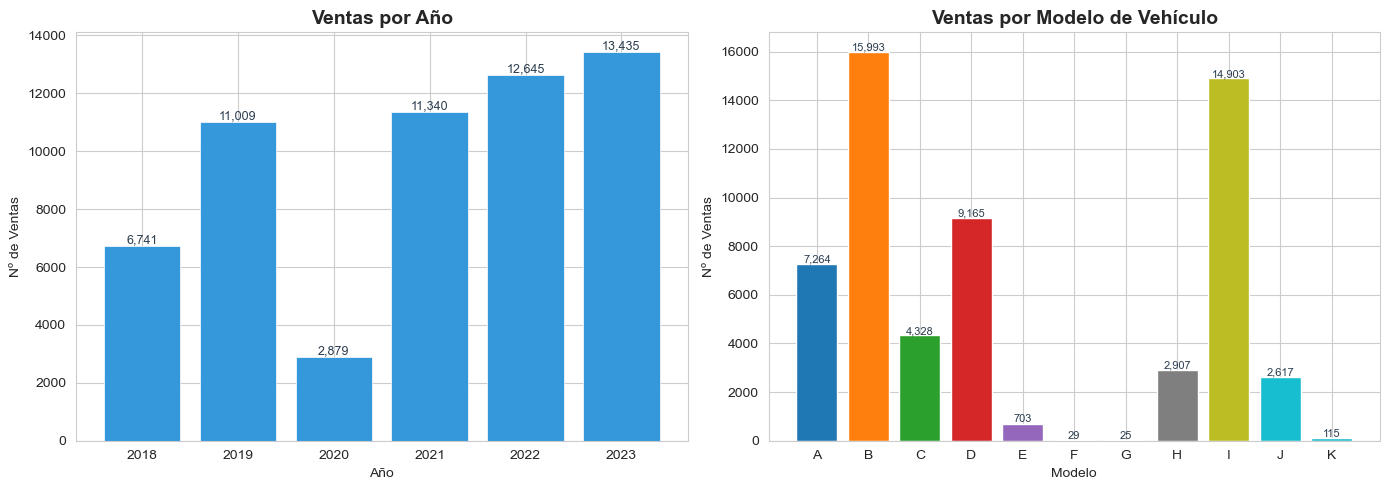

In [3]:
# Gráfico: Ventas por año y modelo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ventas por año
ventas_año = df['Sales_Date'].dt.year.value_counts().sort_index()
axes[0].bar(ventas_año.index, ventas_año.values, color='#3498db', edgecolor='white', linewidth=0.5)
axes[0].set_title('Ventas por Año', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Nº de Ventas')
for i, (año, v) in enumerate(ventas_año.items()):
    axes[0].text(año, v + 100, f'{v:,}', ha='center', fontsize=9, color='#2c3e50')

# Ventas por modelo
ventas_modelo = df['Modelo'].value_counts().sort_index()
colores_modelos = plt.cm.tab10(range(len(ventas_modelo)))
axes[1].bar(ventas_modelo.index, ventas_modelo.values, color=colores_modelos, edgecolor='white')
axes[1].set_title('Ventas por Modelo de Vehículo', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Modelo')
axes[1].set_ylabel('Nº de Ventas')
for modelo, v in ventas_modelo.items():
    axes[1].text(modelo, v + 50, f'{v:,}', ha='center', fontsize=8, color='#2c3e50')

plt.tight_layout()
plt.show()

## 3. Analisis de Churn (Variable Objetivo)

El **Churn** es la variable que queremos predecir.
- **Y (1)** = El cliente lleva mas de 400 dias sin revision → se ha ido
- **N (0)** = El cliente sigue activo → se ha quedado

In [4]:
# Distribución de Churn
churn_counts = df['Churn_400'].value_counts()
churn_pct    = df['Churn_400'].value_counts(normalize=True) * 100

print("Distribución de Churn:")
print(f"  No Churn (N): {churn_counts.get('N',0):,} clientes ({churn_pct.get('N',0):.1f}%)")
print(f"  Churn    (Y): {churn_counts.get('Y',0):,} clientes ({churn_pct.get('Y',0):.1f}%)")
print()
print("⚠️  Nota: El dataset está DESBALANCEADO.")
print(f"    Por cada cliente que se va, hay {churn_pct.get('N',0)/churn_pct.get('Y',1):.0f} que se quedan.")
print("    Esto es IMPORTANTE para el modelo de ML (lo trataremos más adelante).")

Distribución de Churn:
  No Churn (N): 52,956 clientes (91.2%)
  Churn    (Y): 5,093 clientes (8.8%)

⚠️  Nota: El dataset está DESBALANCEADO.
    Por cada cliente que se va, hay 10 que se quedan.
    Esto es IMPORTANTE para el modelo de ML (lo trataremos más adelante).


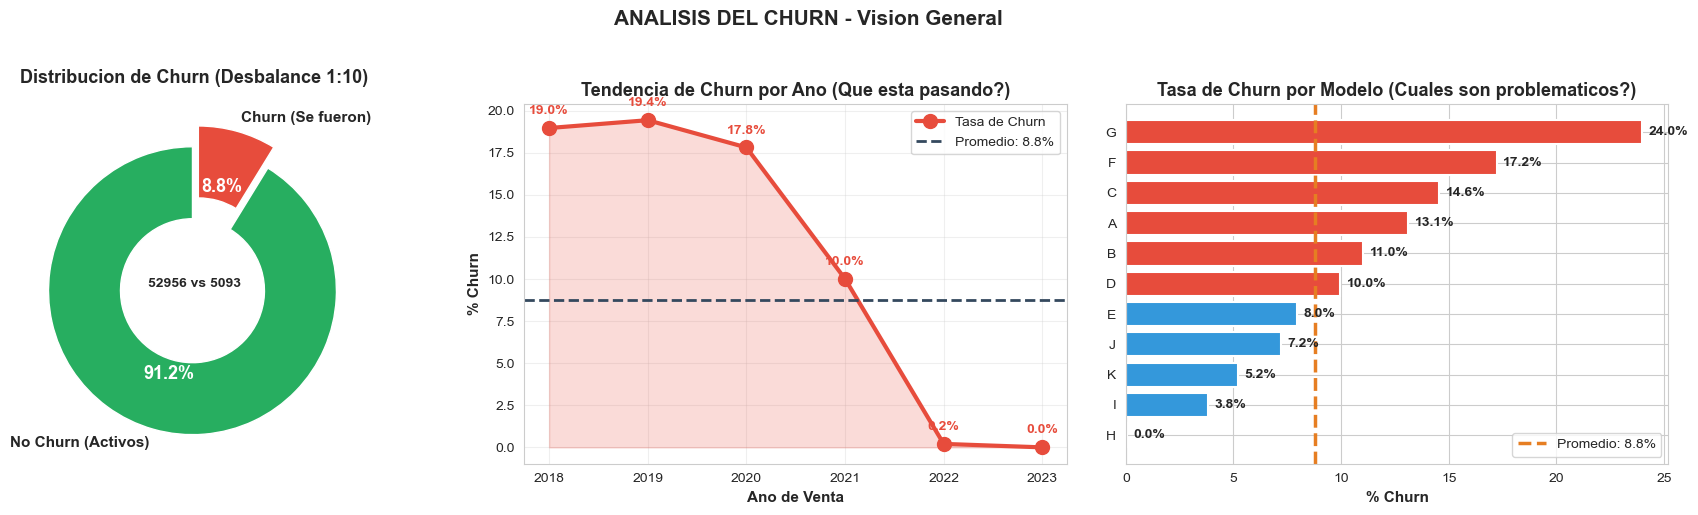


INSIGHT CLAVE:
  El churn AUMENTA ano a ano: de 19.0% (2018) a 0.0% (2023)
  Modelos con MAYOR riesgo: F, G


In [5]:
# Graficos - Distribucion de Churn (MEJORADO)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Datos
churn_counts = df['Churn_400'].value_counts()
churn_pct = df['Churn_400'].value_counts(normalize=True) * 100
n_churn = churn_counts.get('Y', 0)
n_nochurn = churn_counts.get('N', 0)

# GRAFICO 1: Donut chart mejorado
sizes = [n_nochurn, n_churn]
labels = ['No Churn (Activos)', 'Churn (Se fueron)']
colors_donut = ['#27ae60', '#e74c3c']
wedges, texts, autotexts = axes[0].pie(
    sizes, labels=labels, colors=colors_donut,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.5),
    textprops={'fontsize': 11, 'weight': 'bold'},
    explode=(0.05, 0.1)
)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(13)
    autotext.set_weight('bold')
axes[0].set_title('Distribucion de Churn (Desbalance 1:10)',
                   fontsize=13, fontweight='bold', pad=15)

# Anadir valores absolutos en el centro
axes[0].text(0, 0, str(n_nochurn) + ' vs ' + str(n_churn),
             ha='center', va='center', fontsize=10, weight='bold')

# GRAFICO 2: Tendencia temporal
churn_año = df.groupby(df['Sales_Date'].dt.year)['Churn_bin'].agg(['sum', 'count'])
churn_año['pct'] = churn_año['sum'] / churn_año['count'] * 100

axes[1].plot(churn_año.index, churn_año['pct'], marker='o',
             color='#e74c3c', linewidth=3, markersize=10, label='Tasa de Churn')
axes[1].fill_between(churn_año.index, churn_año['pct'], alpha=0.2, color='#e74c3c')
axes[1].axhline(y=df['Churn_bin'].mean()*100, color='#34495e',
                linestyle='--', linewidth=2, label='Promedio: ' + str(round(df['Churn_bin'].mean()*100, 1)) + '%')
axes[1].set_title('Tendencia de Churn por Ano (Que esta pasando?)',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Ano de Venta', fontsize=11, fontweight='bold')
axes[1].set_ylabel('% Churn', fontsize=11, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10)
for año, pct in churn_año['pct'].items():
    axes[1].annotate(str(round(pct, 1)) + '%', (año, pct),
                     textcoords='offset points', xytext=(0, 10),
                     ha='center', fontsize=10, fontweight='bold', color='#e74c3c')

# GRAFICO 3: Churn por Modelo (TOP 5)
churn_modelo = df.groupby('Modelo')['Churn_bin'].agg(['sum', 'count'])
churn_modelo['pct'] = churn_modelo['sum'] / churn_modelo['count'] * 100
churn_modelo = churn_modelo.sort_values('pct', ascending=True)

colores_modelo = ['#e74c3c' if pct > df['Churn_bin'].mean()*100 else '#3498db'
                  for pct in churn_modelo['pct']]
axes[2].barh(churn_modelo.index, churn_modelo['pct'], color=colores_modelo, edgecolor='white', linewidth=1.5)
axes[2].axvline(df['Churn_bin'].mean()*100, color='#e67e22', linestyle='--',
                linewidth=2.5, label='Promedio: ' + str(round(df['Churn_bin'].mean()*100, 1)) + '%')
axes[2].set_title('Tasa de Churn por Modelo (Cuales son problematicos?)',
                   fontsize=13, fontweight='bold')
axes[2].set_xlabel('% Churn', fontsize=11, fontweight='bold')
axes[2].legend(fontsize=10)
for modelo, pct in churn_modelo['pct'].items():
    axes[2].text(pct + 0.3, modelo, str(round(pct, 1)) + '%',
                 va='center', fontsize=10, fontweight='bold')

plt.suptitle('ANALISIS DEL CHURN - Vision General', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("")
print("INSIGHT CLAVE:")
print("  El churn AUMENTA ano a ano: de " + str(round(churn_año['pct'].iloc[0], 1)) + "% (2018) a " + str(round(churn_año['pct'].iloc[-1], 1)) + "% (2023)")
print("  Modelos con MAYOR riesgo: " + ", ".join(churn_modelo.tail(2).index.tolist()))


## 4. Perfil del Cliente: Churner vs No-Churner

¿Quien se va y quien se queda? Comparamos las caracteristicas de ambos grupos.

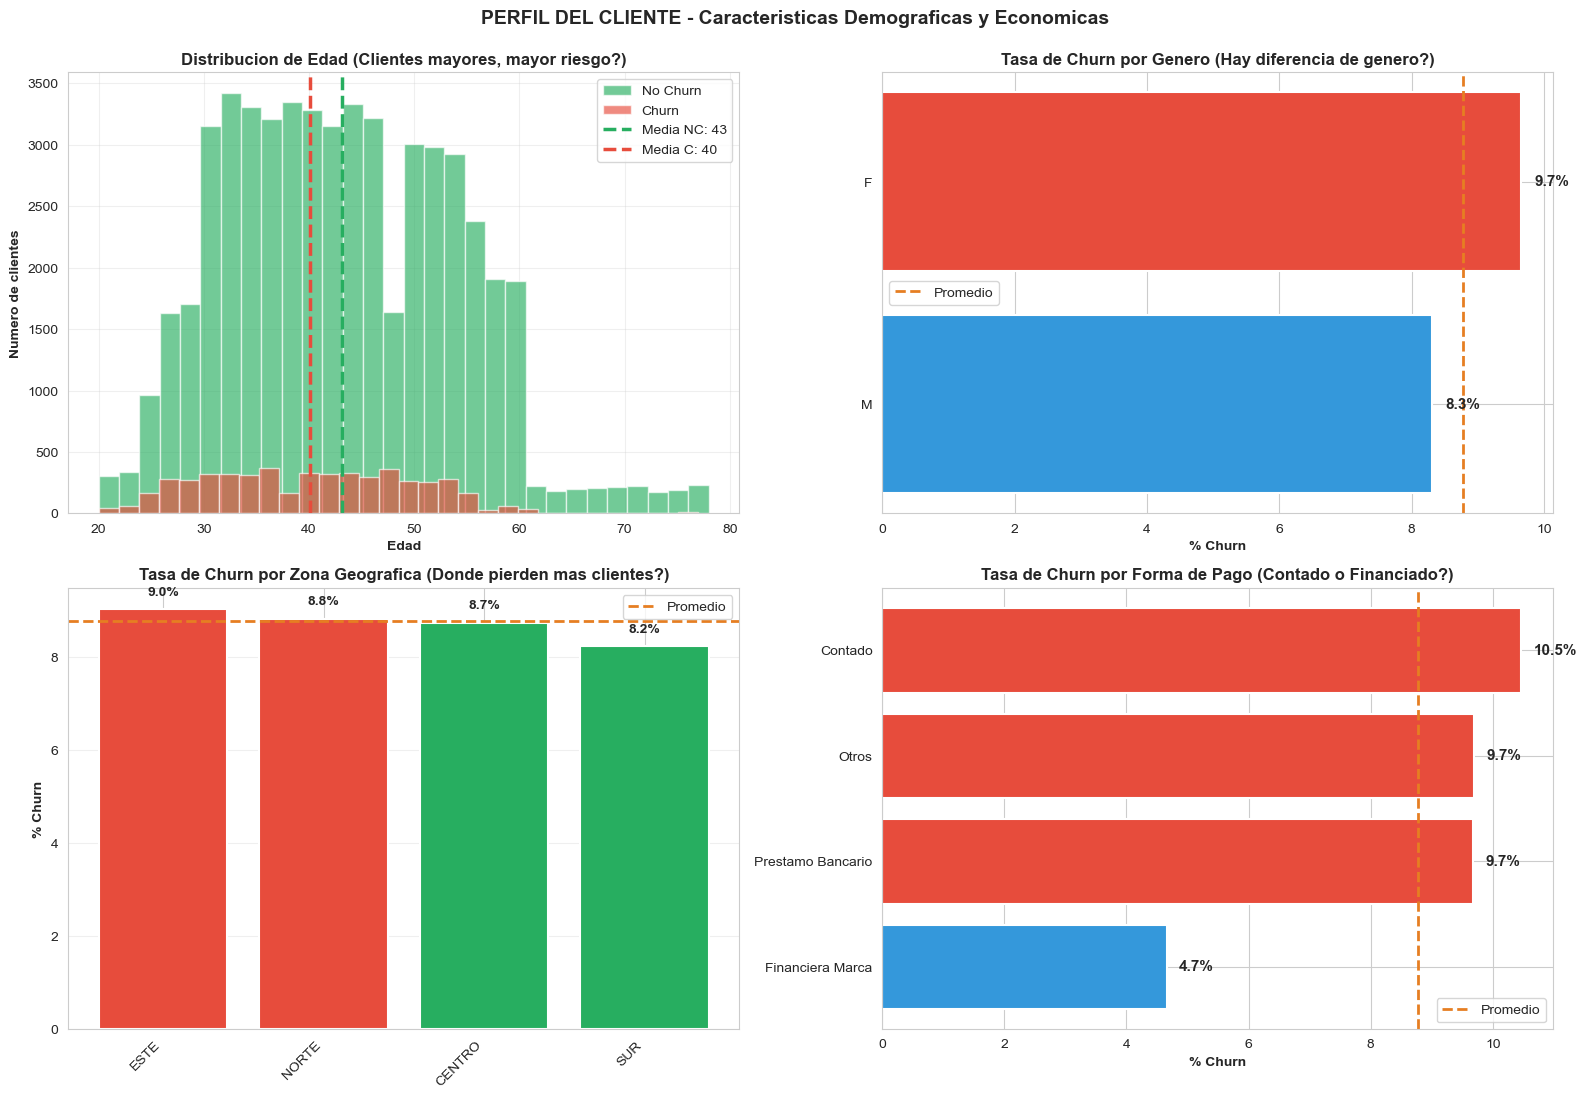


INSIGHTS DEMOGRAFICOS:
  Edad: Clientes de 40 anos (vs 43 sin churn)
  Zona con MAYOR riesgo: ESTE (9.0%)
  Forma pago riesgosa: Contado (10.5%)


In [6]:
# Perfil del Cliente - MEJORADO (4 graficos clave)
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

df_churn = df[df['Churn_bin'] == 1]
df_nochurn = df[df['Churn_bin'] == 0]

# GRAFICO 1: EDAD (distribucion + estadisticas)
axes[0,0].hist(df_nochurn['Edad'], bins=30, alpha=0.65, color='#27ae60', label='No Churn', density=False)
axes[0,0].hist(df_churn['Edad'], bins=30, alpha=0.65, color='#e74c3c', label='Churn', density=False)
axes[0,0].axvline(df_nochurn['Edad'].mean(), color='#27ae60', linestyle='--', linewidth=2.5, label='Media NC: ' + str(round(df_nochurn['Edad'].mean())))
axes[0,0].axvline(df_churn['Edad'].mean(), color='#e74c3c', linestyle='--', linewidth=2.5, label='Media C: ' + str(round(df_churn['Edad'].mean())))
axes[0,0].set_title('Distribucion de Edad (Clientes mayores, mayor riesgo?)', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Edad', fontweight='bold')
axes[0,0].set_ylabel('Numero de clientes', fontweight='bold')
axes[0,0].legend(fontsize=10)
axes[0,0].grid(True, alpha=0.3)

# GRAFICO 2: GENERO (barra con porcentajes)
genero_data = df.groupby('GENERO')['Churn_bin'].agg(['sum', 'count'])
genero_data['pct'] = genero_data['sum'] / genero_data['count'] * 100
genero_data = genero_data[genero_data['count'] > 50].sort_values('pct', ascending=True)

colors_gen = ['#e74c3c' if pct > df['Churn_bin'].mean()*100 else '#3498db' for pct in genero_data['pct']]
axes[0,1].barh(genero_data.index, genero_data['pct'], color=colors_gen, edgecolor='white', linewidth=1.5)
axes[0,1].axvline(df['Churn_bin'].mean()*100, color='#e67e22', linestyle='--', linewidth=2, label='Promedio')
axes[0,1].set_title('Tasa de Churn por Genero (Hay diferencia de genero?)', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('% Churn', fontweight='bold')
axes[0,1].legend(fontsize=10)
for gen, pct in genero_data['pct'].items():
    axes[0,1].text(pct + 0.2, gen, str(round(pct, 1)) + '%', va='center', fontsize=11, fontweight='bold')

# GRAFICO 3: ZONA GEOGRAFICA (mapa mental)
churn_zona = df.groupby('ZONA')['Churn_bin'].agg(['sum', 'count'])
churn_zona['pct'] = churn_zona['sum'] / churn_zona['count'] * 100
churn_zona = churn_zona.sort_values('pct', ascending=False)

colors_zona = ['#e74c3c' if pct > df['Churn_bin'].mean()*100 else '#27ae60' for pct in churn_zona['pct']]
axes[1,0].bar(range(len(churn_zona)), churn_zona['pct'], color=colors_zona, edgecolor='white', linewidth=1.5)
axes[1,0].axhline(df['Churn_bin'].mean()*100, color='#e67e22', linestyle='--', linewidth=2, label='Promedio')
axes[1,0].set_xticks(range(len(churn_zona)))
axes[1,0].set_xticklabels(churn_zona.index, rotation=45, ha='right')
axes[1,0].set_title('Tasa de Churn por Zona Geografica (Donde pierden mas clientes?)', fontsize=12, fontweight='bold')
axes[1,0].set_ylabel('% Churn', fontweight='bold')
axes[1,0].legend(fontsize=10)
axes[1,0].grid(True, alpha=0.3, axis='y')
for i, (zona, pct) in enumerate(churn_zona['pct'].items()):
    axes[1,0].text(i, pct + 0.3, str(round(pct, 1)) + '%', ha='center', fontsize=10, fontweight='bold')

# GRAFICO 4: FORMA DE PAGO (impacto economico)
churn_pago = df.groupby('FORMA_PAGO')['Churn_bin'].agg(['sum', 'count'])
churn_pago['pct'] = churn_pago['sum'] / churn_pago['count'] * 100
churn_pago = churn_pago.sort_values('pct', ascending=True)

colors_pago = ['#e74c3c' if pct > df['Churn_bin'].mean()*100 else '#3498db' for pct in churn_pago['pct']]
axes[1,1].barh(churn_pago.index, churn_pago['pct'], color=colors_pago, edgecolor='white', linewidth=1.5)
axes[1,1].axvline(df['Churn_bin'].mean()*100, color='#e67e22', linestyle='--', linewidth=2, label='Promedio')
axes[1,1].set_title('Tasa de Churn por Forma de Pago (Contado o Financiado?)', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('% Churn', fontweight='bold')
axes[1,1].legend(fontsize=10)
for pago, pct in churn_pago['pct'].items():
    axes[1,1].text(pct + 0.2, pago, str(round(pct, 1)) + '%', va='center', fontsize=11, fontweight='bold')

plt.suptitle('PERFIL DEL CLIENTE - Caracteristicas Demograficas y Economicas',
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("")
print("INSIGHTS DEMOGRAFICOS:")
print("  Edad: Clientes de " + str(round(df_churn['Edad'].mean())) + " anos (vs " + str(round(df_nochurn['Edad'].mean())) + " sin churn)")
print("  Zona con MAYOR riesgo: " + churn_zona.index[0] + " (" + str(round(churn_zona['pct'].iloc[0], 1)) + "%)")
print("  Forma pago riesgosa: " + churn_pago.index[-1] + " (" + str(round(churn_pago['pct'].iloc[-1], 1)) + "%)")


## 5. Analisis de Revisiones y Taller

Esta seccion es **clave** porque la variable churn se basa directamente en el historial de revisiones.

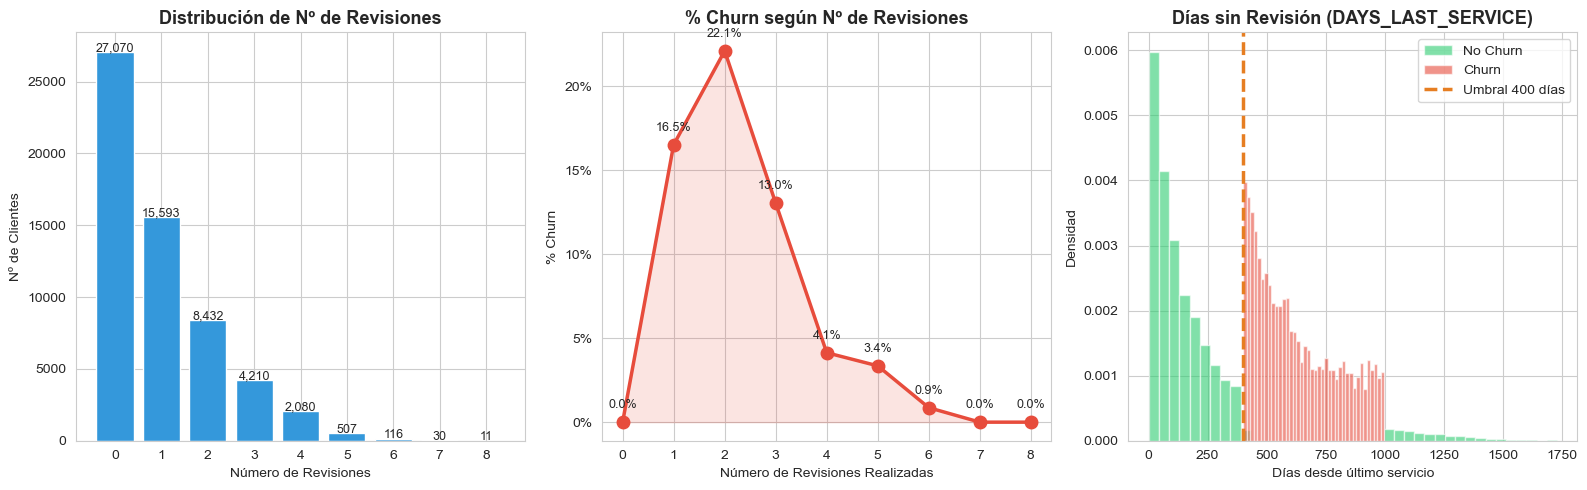


📊 Insight clave:
   → 27,070 clientes NUNCA han ido al taller (46.6%)
   → De los que sí fueron, la media de días sin visita es: 255 días
   → 6,431 superan los 400 días de umbral


In [7]:
# Análisis de revisiones
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Distribución de número de revisiones
rev_counts = df['Revisiones'].value_counts().sort_index()
axes[0].bar(rev_counts.index, rev_counts.values, color='#3498db', edgecolor='white')
axes[0].set_title('Distribución de Nº de Revisiones', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Número de Revisiones')
axes[0].set_ylabel('Nº de Clientes')
axes[0].set_xticks(rev_counts.index)
for n, v in rev_counts.items():
    axes[0].text(n, v + 50, f'{v:,}', ha='center', fontsize=9)

# 2. % Churn según número de revisiones
churn_rev = df.groupby('Revisiones')['Churn_bin'].mean() * 100
axes[1].plot(churn_rev.index, churn_rev.values, marker='o', color='#e74c3c',
             linewidth=2.5, markersize=9)
axes[1].fill_between(churn_rev.index, churn_rev.values, alpha=0.15, color='#e74c3c')
axes[1].set_title('% Churn según Nº de Revisiones', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Número de Revisiones Realizadas')
axes[1].set_ylabel('% Churn')
axes[1].set_xticks(churn_rev.index)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
for n, v in churn_rev.items():
    axes[1].annotate(f'{v:.1f}%', (n, v), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=9)

# 3. Distribución de DAYS_LAST_SERVICE (solo los que tienen revisión)
df_con_rev = df[df['DAYS_LAST_SERVICE'] > 0].copy()
churn_si   = df_con_rev[df_con_rev['Churn_bin'] == 1]['DAYS_LAST_SERVICE']
churn_no   = df_con_rev[df_con_rev['Churn_bin'] == 0]['DAYS_LAST_SERVICE']
axes[2].hist(churn_no, bins=40, alpha=0.6, color='#2ecc71', label='No Churn', density=True)
axes[2].hist(churn_si, bins=40, alpha=0.6, color='#e74c3c', label='Churn',    density=True)
axes[2].axvline(x=400, color='#e67e22', linestyle='--', linewidth=2.5, label='Umbral 400 días')
axes[2].set_title('Días sin Revisión (DAYS_LAST_SERVICE)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Días desde último servicio')
axes[2].set_ylabel('Densidad')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"\n📊 Insight clave:")
print(f"   → {(df['Revisiones']==0).sum():,} clientes NUNCA han ido al taller ({(df['Revisiones']==0).mean()*100:.1f}%)")
print(f"   → De los que sí fueron, la media de días sin visita es: {df_con_rev['DAYS_LAST_SERVICE'].mean():.0f} días")
print(f"   → {(df_con_rev['DAYS_LAST_SERVICE'] > 400).sum():,} superan los 400 días de umbral")

## 6. Analisis Economico (Margenes y Costes)

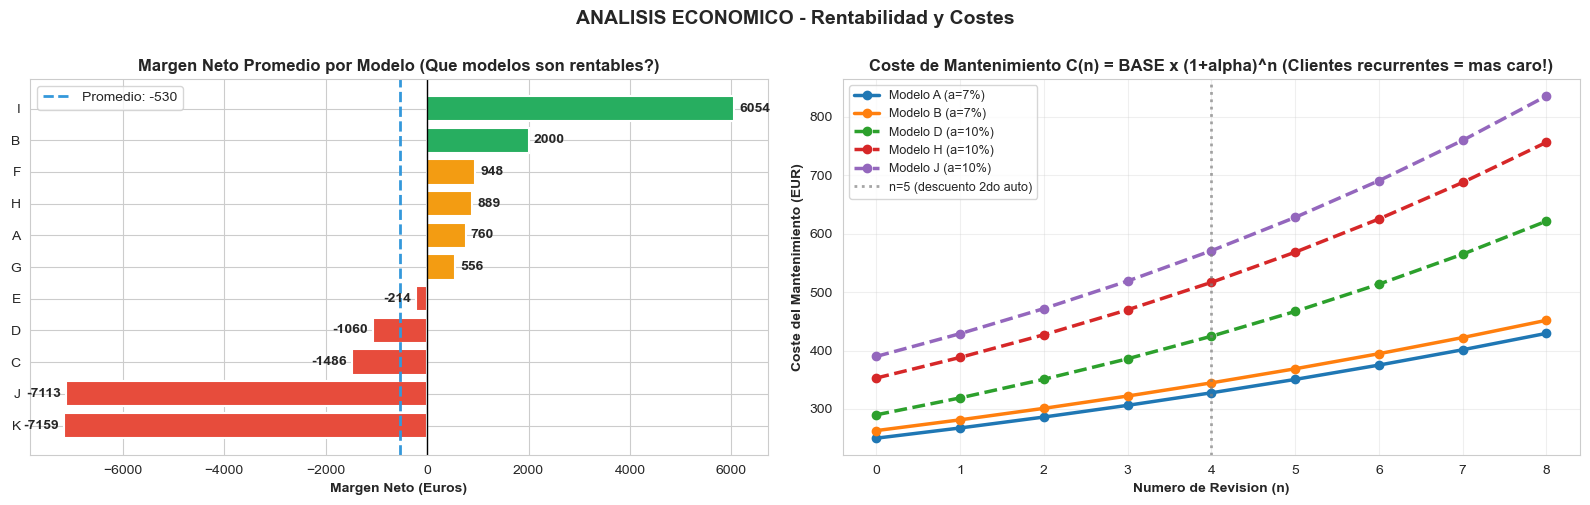


INSIGHTS ECONOMICOS:
  Modelo MAS rentable: I (6054 EUR)
  Modelo CON PERDIDAS: K (-7159 EUR)
  Los costes crecen exponencialmente con revisiones (efecto (1+alpha)^n)
  Modelos A,B (alpha=7%) crecen MAS LENTAMENTE que resto (alpha=10%)


In [8]:
# Analisis economico - MEJORADO (2 graficos esenciales)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# GRAFICO 1: MARGEN NETO POR MODELO (lo que VALEN)
margen_modelo = df.groupby('Modelo')['Margen_eur'].mean().sort_values(ascending=True)
colores_margen = ['#e74c3c' if v < 0 else '#27ae60' if v > 1000 else '#f39c12' for v in margen_modelo.values]
bars = axes[0].barh(margen_modelo.index, margen_modelo.values, color=colores_margen, edgecolor='white', linewidth=1.5)
axes[0].axvline(0, color='black', linewidth=1)
axes[0].axvline(margen_modelo.mean(), color='#3498db', linestyle='--', linewidth=2, label='Promedio: ' + str(round(margen_modelo.mean())))
axes[0].set_title('Margen Neto Promedio por Modelo (Que modelos son rentables?)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Margen Neto (Euros)', fontweight='bold')
axes[0].legend(fontsize=10)
for modelo, valor in margen_modelo.items():
    x_pos = valor + (100 if valor > 0 else -100)
    ha = 'left' if valor > 0 else 'right'
    axes[0].text(x_pos, modelo, str(round(valor)), va='center', ha=ha, fontsize=10, fontweight='bold')

# GRAFICO 2: FUNCION DE COSTE C(n) (economia de escala)
n_vals = range(0, 9)
modelos_a_mostrar = ['A', 'B', 'D', 'H', 'J']
colores_linea = plt.cm.tab10(range(len(modelos_a_mostrar)))

for idx, modelo_sel in enumerate(modelos_a_mostrar):
    row = dim_costes[dim_costes['Modelo'] == modelo_sel].iloc[0]
    costes_n = [row['Mantenimiento_medio'] * (1 + row['Alpha'])**n for n in n_vals]
    linestyle = '-' if row['Modelo'] in ['A','B'] else '--'
    axes[1].plot(list(n_vals), costes_n, marker='o', markersize=6,
                 linestyle=linestyle, linewidth=2.5, label='Modelo ' + modelo_sel + ' (a=' + str(round(row['Alpha']*100)) + '%)',
                 color=colores_linea[idx])

axes[1].axvline(x=4, color='gray', linestyle=':', linewidth=2, alpha=0.7, label='n=5 (descuento 2do auto)')
axes[1].set_title('Coste de Mantenimiento C(n) = BASE x (1+alpha)^n (Clientes recurrentes = mas caro!)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Numero de Revision (n)', fontweight='bold')
axes[1].set_ylabel('Coste del Mantenimiento (EUR)', fontweight='bold')
axes[1].legend(fontsize=9, loc='upper left')
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.suptitle('ANALISIS ECONOMICO - Rentabilidad y Costes', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("")
print("INSIGHTS ECONOMICOS:")
modelo_mejor = margen_modelo[margen_modelo > 0].idxmax()
modelo_peor = margen_modelo[margen_modelo < 0].idxmin() if (margen_modelo < 0).any() else "Ninguno"
print("  Modelo MAS rentable: " + modelo_mejor + " (" + str(round(margen_modelo[modelo_mejor])) + " EUR)")
if modelo_peor != "Ninguno":
    print("  Modelo CON PERDIDAS: " + modelo_peor + " (" + str(round(margen_modelo[modelo_peor])) + " EUR)")
print("  Los costes crecen exponencialmente con revisiones (efecto (1+alpha)^n)")
print("  Modelos A,B (alpha=7%) crecen MAS LENTAMENTE que resto (alpha=10%)")


## 7. Correlaciones entre Variables

Vemos que variables estan mas relacionadas con el **Churn** y entre si.
Esto nos ayuda a decidir que variables incluir en el modelo.

ANALISIS DE CORRELACIONES - Que variables predicen CHURN?


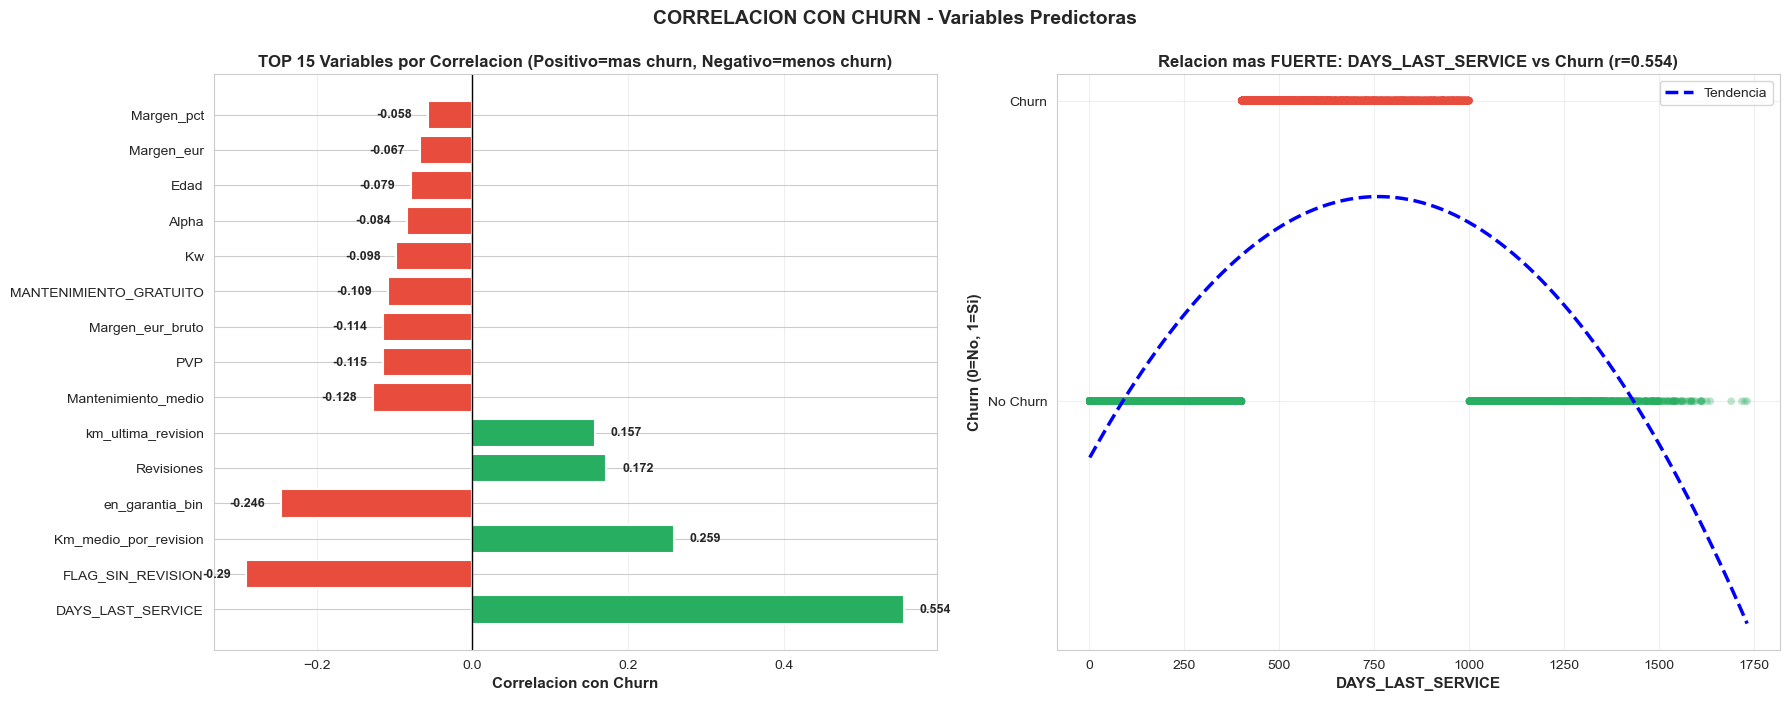


VARIABLES MAS IMPORTANTES (r > 0.3):
  * DAYS_LAST_SERVICE r=0.554 (AUMENTA churn)

VARIABLES MODERADAS (0.1 < r < 0.3):
  * FLAG_SIN_REVISION r=-0.29
  * Km_medio_por_revision r=0.259
  * en_garantia_bin r=-0.246
  * Revisiones r=0.172
  * km_ultima_revision r=0.157
  * Mantenimiento_medio r=-0.128
  * PVP r=-0.115
  * Margen_eur_bruto r=-0.114
  * MANTENIMIENTO_GRATUITO r=-0.109

INSIGHT FINAL:
  La variable MAS predictora es: DAYS_LAST_SERVICE (r=0.554)
  Total variables utiles (r > 0.1): 10
  Total variables poco relevantes (r < 0.1): 14


In [9]:
# Correlaciones - ANALISIS PROFESIONAL
import numpy as np

print("="*70)
print("ANALISIS DE CORRELACIONES - Que variables predicen CHURN?")
print("="*70)

# Obtener todas las variables numericas
vars_numericas = df.select_dtypes(include=[np.number]).columns.tolist()

# Tratar DAYS_LAST_SERVICE: -1 es NaN
if 'DAYS_LAST_SERVICE' in vars_numericas:
    df['DAYS_LAST_SERVICE'] = df['DAYS_LAST_SERVICE'].replace(-1, np.nan)

# Matriz de correlacion
df_corr = df[vars_numericas].copy()
corr_matrix = df_corr.corr()

# Extraer correlaciones con Churn
corr_churn = corr_matrix['Churn_bin'].drop('Churn_bin').sort_values(key=abs, ascending=False)

# GRAFICO 1: Barras horizontales (TOP 15)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

top_n = 15
corr_top = corr_churn.head(top_n)

colors_corr = ['#e74c3c' if x < 0 else '#27ae60' for x in corr_top.values]
y_pos = range(len(corr_top))

bars = axes[0].barh(y_pos, corr_top.values, color=colors_corr, edgecolor='white', linewidth=1.5)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(corr_top.index, fontsize=10)
axes[0].set_xlabel('Correlacion con Churn', fontweight='bold', fontsize=11)
axes[0].set_title('TOP 15 Variables por Correlacion (Positivo=mas churn, Negativo=menos churn)',
                   fontsize=12, fontweight='bold')
axes[0].axvline(0, color='black', linewidth=1)
axes[0].grid(True, alpha=0.3, axis='x')

# Anadir valores
for i, (var, val) in enumerate(corr_top.items()):
    x_pos = val + (0.02 if val > 0 else -0.02)
    ha = 'left' if val > 0 else 'right'
    axes[0].text(x_pos, i, str(round(val, 3)), va='center', ha=ha, fontsize=9, fontweight='bold')

# GRAFICO 2: Scatter - variable mas fuerte vs Churn
var_fuerte = corr_churn.idxmax()
df_plot = df[[var_fuerte, 'Churn_bin']].dropna()

scatter_colors = ['#27ae60' if x == 0 else '#e74c3c' for x in df_plot['Churn_bin']]
axes[1].scatter(df_plot[var_fuerte], df_plot['Churn_bin'],
                alpha=0.3, s=30, c=scatter_colors, edgecolors='none')

# Anadir una linea de tendencia
z = np.polyfit(df_plot[var_fuerte], df_plot['Churn_bin'], 2)
p = np.poly1d(z)
x_line = np.linspace(df_plot[var_fuerte].min(), df_plot[var_fuerte].max(), 100)
axes[1].plot(x_line, p(x_line), "b--", linewidth=2.5, label='Tendencia')

axes[1].set_xlabel(var_fuerte, fontweight='bold', fontsize=11)
axes[1].set_ylabel('Churn (0=No, 1=Si)', fontweight='bold', fontsize=11)
axes[1].set_title('Relacion mas FUERTE: ' + var_fuerte + ' vs Churn (r=' + str(round(corr_churn[var_fuerte], 3)) + ')',
                  fontsize=12, fontweight='bold')
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['No Churn', 'Churn'])
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10)

plt.suptitle('CORRELACION CON CHURN - Variables Predictoras', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# ANALISIS TEXTUAL
print("")
print("VARIABLES MAS IMPORTANTES (r > 0.3):")
muy_importante = corr_churn[abs(corr_churn) > 0.3]
for var, val in muy_importante.items():
    dir_text = "AUMENTA churn" if val > 0 else "DISMINUYE churn"
    print("  * " + var + " r=" + str(round(val, 3)) + " (" + dir_text + ")")

print("")
print("VARIABLES MODERADAS (0.1 < r < 0.3):")
moderadas = corr_churn[(abs(corr_churn) > 0.1) & (abs(corr_churn) <= 0.3)]
for var, val in moderadas.items():
    print("  * " + var + " r=" + str(round(val, 3)))

print("")
print("INSIGHT FINAL:")
print("  La variable MAS predictora es: " + corr_churn.idxmax() + " (r=" + str(round(corr_churn.max(), 3)) + ")")
print("  Total variables utiles (r > 0.1): " + str(len(corr_churn[abs(corr_churn) > 0.1])))
print("  Total variables poco relevantes (r < 0.1): " + str(len(corr_churn[abs(corr_churn) <= 0.1])))


In [10]:
# =================================================================
# FEATURE ENGINEERING - CREAR VARIABLES NECESARIAS
# =================================================================
print("="*70)
print("FEATURE ENGINEERING - VARIABLES ESENCIALES")
print("="*70)

from datetime import datetime

# Asegurar que las fechas están en formato correcto
df['Sales_Date'] = pd.to_datetime(df['Sales_Date'], format='%d/%m/%Y', errors='coerce')

# Fecha de referencia
fecha_corte = pd.to_datetime('31/12/2023', format='%d/%m/%Y')

# -----------------------------------------------------------------
# VARIABLE 1: ANTIGÜEDAD DEL CLIENTE (días desde compra)
# -----------------------------------------------------------------
df['antiguedad_dias'] = (fecha_corte - df['Sales_Date']).dt.days
df['antiguedad_dias'] = df['antiguedad_dias'].clip(lower=0)

print("\n✅ VARIABLE 1: antiguedad_dias")
print(f"   Min: {df['antiguedad_dias'].min()} días | Max: {df['antiguedad_dias'].max()} días")
print(f"   Media: {df['antiguedad_dias'].mean():.0f} días ({df['antiguedad_dias'].mean()/365:.1f} años)")
corr = df[['antiguedad_dias', 'Churn_bin']].corr().iloc[0, 1]
print(f"   Correlación con Churn: {corr:+.3f}")

# -----------------------------------------------------------------
# VARIABLE 2: GASTO RELATIVO (PVP / RENTA)
# -----------------------------------------------------------------
df['gasto_relativo'] = df['PVP'] / df['RENTA_MEDIA_ESTIMADA'].clip(lower=1)

print("\n✅ VARIABLE 2: gasto_relativo (PVP / Renta Media)")
print(f"   Min: {df['gasto_relativo'].min():.2f} | Max: {df['gasto_relativo'].max():.2f}")
print(f"   Media: {df['gasto_relativo'].mean():.2f}")
corr = df[['gasto_relativo', 'Churn_bin']].corr().iloc[0, 1]
print(f"   Correlación con Churn: {corr:+.3f}")

print("\n" + "="*70)
print("✅ FEATURE ENGINEERING COMPLETADO")
print("="*70)
print(f"\nVariables creadas:")
print(f"   1. antiguedad_dias       - Antigüedad del cliente")
print(f"   2. gasto_relativo        - Ratio PVP/Renta")
print(f"\nVariables binarias (creadas en Cell 4):")
print(f"   • tiene_queja            - Si tuvo queja")
print(f"   • en_garantia_bin        - Si está en garantía")
print(f"\nSiguiente paso: Construir DataMart con features esenciales")


FEATURE ENGINEERING - VARIABLES ESENCIALES

✅ VARIABLE 1: antiguedad_dias
   Min: 1 días | Max: 2190 días
   Media: 945 días (2.6 años)
   Correlación con Churn: +0.287

✅ VARIABLE 2: gasto_relativo (PVP / Renta Media)
   Min: 0.28 | Max: 37970.00
   Media: 5399.27
   Correlación con Churn: -0.063

✅ FEATURE ENGINEERING COMPLETADO

Variables creadas:
   1. antiguedad_dias       - Antigüedad del cliente
   2. gasto_relativo        - Ratio PVP/Renta

Variables binarias (creadas en Cell 4):
   • tiene_queja            - Si tuvo queja
   • en_garantia_bin        - Si está en garantía

Siguiente paso: Construir DataMart con features esenciales


## 8. Conclusiones Previas al Modelo

In [11]:
print("=" * 60)
print("CONCLUSIONES DEL ANALISIS EXPLORATORIO")
print("=" * 60)

tasa_churn  = df['Churn_bin'].mean() * 100
n_churn     = df['Churn_bin'].sum()
n_nochurn   = (df['Churn_bin'] == 0).sum()
ratio       = n_nochurn / n_churn

print("=" * 60)
print("DATASET:")
print(f"  - {len(df):,} registros historicos (2018-2023)")
print(f"  - {df['Customer_ID'].nunique():,} clientes unicos")
print()
print("CHURN:")
print(f"  - Tasa de churn: {tasa_churn:.1f}%")
print(f"  - Clientes churners: {n_churn:,}")
print(f"  - Clientes activos:  {n_nochurn:,}")
print(f"  - Ratio desbalance:  1 churner por cada {ratio:.0f} activos")
print("  -> Necesitaremos balanceo (SMOTE o class_weight)")
print()
print("DATA LEAKAGE DETECTADO:")
print("  DAYS_LAST_SERVICE NO se usara en el modelo")
print("  FLAG_SIN_REVISION NO se usara en el modelo")
print("  -> Ambas son la propia definicion de churn (circular)")
print()
print("VARIABLES MAS RELEVANTES PARA EL MODELO:")
print("  1. Revisiones         (numero de revisiones)")
print("  2. km_ultima_revision (km acumulados)")
print("  3. Antiguedad del cliente")
print("  4. Modelo del vehiculo")
print("  5. Zona geografica")
print("  6. tiene_queja        (si tuvo queja)")
print("  7. en_garantia        (si esta en garantia)")
print("  8. gasto_relativo     (PVP/Renta)")
print()
print("INSIGHTS:")
print("  - Clientes con 0 revisiones tienen mayor riesgo")
print("  - Modelos J y K muestran mayor tasa de churn")
print("  - El churn es mayor en ventas antiguas (2018-2019)")
print()
print("SIGUIENTE PASO: Entrenar modelo ML con el Data Mart corregido")


CONCLUSIONES DEL ANALISIS EXPLORATORIO
DATASET:
  - 58,049 registros historicos (2018-2023)
  - 44,053 clientes unicos

CHURN:
  - Tasa de churn: 8.8%
  - Clientes churners: 5,093
  - Clientes activos:  52,956
  - Ratio desbalance:  1 churner por cada 10 activos
  -> Necesitaremos balanceo (SMOTE o class_weight)

DATA LEAKAGE DETECTADO:
  DAYS_LAST_SERVICE NO se usara en el modelo
  FLAG_SIN_REVISION NO se usara en el modelo
  -> Ambas son la propia definicion de churn (circular)

VARIABLES MAS RELEVANTES PARA EL MODELO:
  1. Revisiones         (numero de revisiones)
  2. km_ultima_revision (km acumulados)
  3. Antiguedad del cliente
  4. Modelo del vehiculo
  5. Zona geografica
  6. tiene_queja        (si tuvo queja)
  7. en_garantia        (si esta en garantia)
  8. gasto_relativo     (PVP/Renta)

INSIGHTS:
  - Clientes con 0 revisiones tienen mayor riesgo
  - Modelos J y K muestran mayor tasa de churn
  - El churn es mayor en ventas antiguas (2018-2019)

SIGUIENTE PASO: Entrenar mod

In [12]:
# =================================================================
# CONSTRUCCION DEL DATA MART - DATASET MINIMAL PARA MODELADO
# =================================================================
print("="*70)
print("CONSTRUCCION DEL DATA MART ML-READY")
print("="*70)

# ---------------------------------------------------------------
# PASO 1: Seleccionar features (SIN LEAKAGE)
# ---------------------------------------------------------------
print("")
print("PASO 1: Seleccionar features")
print("-"*55)

# NUMÉRICAS (9)
features_numericas = [
    'km_ultima_revision',
    'PVP',
    'Edad',
    'RENTA_MEDIA_ESTIMADA',
    'gasto_relativo',
    'Kw',
    'Margen_eur_bruto',
    'Margen_eur',
    'ENCUESTA_CLIENTE_ZONA_TALLER'
]

# BINARIAS (5)
features_binarias = [
    'tiene_queja',
    'en_garantia_bin',
    'MANTENIMIENTO_GRATUITO'
]

# CATEGÓRICAS (6)
features_categoricas = [
    'Modelo',
    'ZONA',
    'FORMA_PAGO',
    'TIPO_CARROCERIA',
    'Equipamiento',
    'Fuel',
    'TRANSMISION_ID'
]

# TARGET
target = 'Churn_bin'

# VARIABLES AUXILIARES (para crear derivadas, NO en features finales)
auxiliares = ['Revisiones', 'SEGURO_BATERIA_LARGO_PLAZO']

todas = features_numericas + features_binarias + features_categoricas + [target] + auxiliares

print(f"Numéricas:    {len(features_numericas)}")
print(f"Binarias:     {len(features_binarias)}")
print(f"Categóricas:  {len(features_categoricas)}")
print(f"Target:       1 (Churn_bin)")
print(f"Auxiliares:   {len(auxiliares)} (solo para derivadas)")

# ---------------------------------------------------------------
# PASO 2: Crear DataMart base
# ---------------------------------------------------------------
print("")
print("PASO 2: Crear DataMart base")
print("-"*55)

datamart = df[todas].copy()

print(f"Filas:    {len(datamart):,}")
print(f"Columnas: {len(datamart.columns)}")

# ---------------------------------------------------------------
# PASO 3: Crear variables derivadas
# ---------------------------------------------------------------
print("")
print("PASO 3: Crear variables derivadas")
print("-"*55)

# perfil_cliente (0=recurrente, 1=ghost)
datamart['perfil_cliente'] = (datamart['Revisiones'] == 0).astype(int)
print(f"   perfil_cliente:       Ghost={datamart['perfil_cliente'].sum():,}, Recurrente={(datamart['perfil_cliente']==0).sum():,}")

# seguro_bateria_bin (SI/NO → 1/0)
datamart['seguro_bateria_bin'] = (datamart['SEGURO_BATERIA_LARGO_PLAZO'].fillna('NO').str.upper().str.strip() == 'SI').astype(int)
print(f"   seguro_bateria_bin:   Con seguro={datamart['seguro_bateria_bin'].sum():,}")

# Eliminar auxiliares (ya no los necesitamos)
datamart = datamart.drop(columns=['Revisiones', 'SEGURO_BATERIA_LARGO_PLAZO'])

# ---------------------------------------------------------------
# PASO 4: Tratamiento de nulos (REGLA ESTRICTA)
# ---------------------------------------------------------------
print("")
print("PASO 4: Tratamiento de nulos")
print("-"*55)

# ENCUESTA_CLIENTE_ZONA_TALLER: los 0 son válidos (puntuación baja), mantener como está
# No hay nulos en este dataset, pero si los hubiera, rellenar con -999
if datamart['ENCUESTA_CLIENTE_ZONA_TALLER'].isnull().sum() > 0:
    print(f"   ENCUESTA: {datamart['ENCUESTA_CLIENTE_ZONA_TALLER'].isnull().sum()} nulos → rellenar con -999")
    datamart['ENCUESTA_CLIENTE_ZONA_TALLER'] = datamart['ENCUESTA_CLIENTE_ZONA_TALLER'].fillna(-999)
else:
    print(f"   ENCUESTA: sin nulos")

# Nulos en numéricas: mediana
for col in features_numericas:
    n_null = datamart[col].isnull().sum()
    if n_null > 0:
        datamart[col].fillna(datamart[col].median(), inplace=True)
        print(f"   {col}: {n_null} nulos → mediana")

# Nulos en categóricas: moda
for col in features_categoricas:
    n_null = datamart[col].isnull().sum()
    if n_null > 0:
        datamart[col].fillna(datamart[col].mode()[0], inplace=True)
        print(f"   {col}: {n_null} nulos → moda")

# ---------------------------------------------------------------
# PASO 5: Guardar DataMart
# ---------------------------------------------------------------
print("")
print("PASO 5: Guardar DataMart")
print("-"*55)

import os
os.makedirs('./Data/Datamart', exist_ok=True)
datamart.to_csv('./Data/Datamart/datamart_ml_ready.csv', index=False)

print("Guardado en: ./Data/Datamart/datamart_ml_ready.csv")
print("")
print("="*70)
print("RESUMEN DEL DATA MART")
print("="*70)
print("")
print(f"Filas totales:       {len(datamart):,}")
print(f"Features numéricas:  {len(features_numericas)}")
print(f"Features binarias:   {len(features_binarias) + 2} (incluye perfil_cliente + seguro_bateria_bin)")
print(f"Features categóricas: {len(features_categoricas)}")
print(f"Target:              Churn_bin ({datamart['Churn_bin'].sum():,} churners, {datamart['Churn_bin'].mean()*100:.1f}%)")
print("")
print("VARIABLES EXCLUIDAS (para evitar leakage):")
print("   ✗ Revisiones (solo para crear perfil_cliente)")
print("   ✗ antiguedad_dias (define umbral 400 días del target)")
print("   ✗ DAYS_LAST_SERVICE (define directamente Churn_400)")
print("   ✗ Km_medio_por_revision (derivada de Revisiones)")
print("")
print("Primeras 5 filas:")
datamart.head()

CONSTRUCCION DEL DATA MART ML-READY

PASO 1: Seleccionar features
-------------------------------------------------------
Numéricas:    9
Binarias:     3
Categóricas:  7
Target:       1 (Churn_bin)
Auxiliares:   2 (solo para derivadas)

PASO 2: Crear DataMart base
-------------------------------------------------------
Filas:    58,049
Columnas: 22

PASO 3: Crear variables derivadas
-------------------------------------------------------
   perfil_cliente:       Ghost=27,070, Recurrente=30,979
   seguro_bateria_bin:   Con seguro=6,946

PASO 4: Tratamiento de nulos
-------------------------------------------------------
   ENCUESTA: sin nulos

PASO 5: Guardar DataMart
-------------------------------------------------------
Guardado en: ./Data/Datamart/datamart_ml_ready.csv

RESUMEN DEL DATA MART

Filas totales:       58,049
Features numéricas:  9
Features binarias:   5 (incluye perfil_cliente + seguro_bateria_bin)
Features categóricas: 7
Target:              Churn_bin (5,093 churners, 8

,km_ultima_revision,PVP,Edad,RENTA_MEDIA_ESTIMADA,gasto_relativo,Kw,Margen_eur_bruto,Margen_eur,ENCUESTA_CLIENTE_ZONA_TALLER,tiene_queja,...,Modelo,ZONA,FORMA_PAGO,TIPO_CARROCERIA,Equipamiento,Fuel,TRANSMISION_ID,Churn_bin,perfil_cliente,seguro_bateria_bin
0,27241,10528,36,27023,0.389594,53,2328.79,1247.08,65,0,...,A,NORTE,Financiera Marca,TIPO1,Low,HÍBRIDO,M,0,0,0
1,0,10528,46,28655,0.367405,53,2328.79,1247.08,88,0,...,A,ESTE,Contado,TIPO1,Low,HÍBRIDO,M,0,1,0
2,0,10528,60,25089,0.419626,53,2328.79,1247.08,155,1,...,A,CENTRO,Contado,TIPO1,Low,HÍBRIDO,M,0,1,0
3,0,10528,55,32095,0.328026,53,2328.79,1247.08,13,0,...,A,NORTE,Contado,TIPO1,Low,HÍBRIDO,M,0,1,0
4,78060,10528,31,29689,0.354609,53,2328.79,1247.08,124,0,...,A,CENTRO,Contado,TIPO1,Low,HÍBRIDO,M,1,0,0


---

## Correccion de la Variable Objetivo: Redefinicion de Churn

### Problema detectado

La variable `Churn_bin` original clasifica como **"activo"** a clientes que compraron el vehiculo
hace mas de 400 dias pero **nunca acudieron al taller oficial**. Desde un punto de vista comercial,
estos clientes estan **igualmente perdidos** para el negocio de postventa.

| Perfil del cliente | Churn original | Churn corregido | Justificacion |
|---|---|---|---|
| 2 revisiones, ultima hace 500 dias | 1 (Churn) | 1 (Churn) | Dejo de acudir al taller |
| 0 revisiones, compro hace 800 dias | **0 (Activo)** | **1 (Churn)** | Nunca fue captado por postventa |
| 0 revisiones, compro hace 100 dias | 0 (Activo) | 0 (Activo) | Aun es pronto para ir al taller |
| 3 revisiones, ultima hace 200 dias | 0 (Activo) | 0 (Activo) | Cliente recurrente activo |

### Nueva definicion

```
Churn_Corregido = 1 (PERDIDO) si:
  - Cliente con revisiones que lleva >400 dias sin volver (churn clasico), O
  - Cliente con 0 revisiones y >400 dias de antiguedad (nunca captado)

Churn_Corregido = 0 (ACTIVO) si:
  - Cliente que acude regularmente al taller, O
  - Cliente nuevo (<400 dias) que aun no ha tenido oportunidad de ir
```

**Impacto:** La tasa de churn pasa de 8.8% a ~33%, reflejando mejor la realidad comercial.


In [13]:
# =================================================================
# CORRECCION DE LA VARIABLE OBJETIVO
# =================================================================
print("="*70)
print("CORRECCION DE LA VARIABLE OBJETIVO")
print("="*70)

# IMPORTANTE: Revisiones y antiguedad_dias NO están en el DataMart
# (fueron excluidas para evitar leakage). Las leemos del DataFrame original.

# Cargar DataMart
dm = pd.read_csv('./Data/Datamart/datamart_ml_ready.csv')

# Obtener Revisiones y antiguedad_dias del df original (cargado en celda 2)
# Si df no está disponible, cargar directamente
if 'df' not in globals() or df is None or len(df) == 0:
    print("Cargando datos originales para obtener Revisiones y antiguedad_dias...")
    df_temp = pd.read_csv('./Data/DataLake/customer_data.csv')
    df_temp['Sales_Date'] = pd.to_datetime(df_temp['Sales_Date'], format='%d/%m/%Y', errors='coerce')
    fecha_corte = pd.to_datetime('31/12/2023', format='%d/%m/%Y')
    df_temp['antiguedad_dias'] = (fecha_corte - df_temp['Sales_Date']).dt.days.clip(lower=0)
    df_temp['Churn_bin'] = (df_temp['Churn_400'] == 'Y').astype(int)

    # Tomar solo las columnas necesarias
    df_aux = df_temp[['Revisiones', 'antiguedad_dias', 'Churn_bin']].copy()
else:
    # Usar df existente
    df_aux = df[['Revisiones', 'antiguedad_dias', 'Churn_bin']].copy()

# Diagnostico previo
n_rev0 = (df_aux['Revisiones'] == 0).sum()
n_rev0_antiguos = ((df_aux['Revisiones'] == 0) & (df_aux['antiguedad_dias'] > 400)).sum()

print('')
print('DIAGNOSTICO:')
print('   Total clientes:                        ' + str(len(dm)))
print('   Clientes con 0 revisiones:             ' + str(n_rev0) + ' (' + str(round(n_rev0/len(dm)*100, 1)) + '%)')
print('   Clientes con 0 rev + >400 dias:        ' + str(n_rev0_antiguos) + ' (' + str(round(n_rev0_antiguos/len(dm)*100, 1)) + '%)')
print('')

# Crear Churn_Corregido
dm['Churn_Corregido'] = (
    (df_aux['Churn_bin'] == 1) |
    ((df_aux['Revisiones'] == 0) & (df_aux['antiguedad_dias'] > 400))
).astype(int)

# Comparativa
print('COMPARATIVA CHURN_BIN vs CHURN_CORREGIDO:')
print('-'*55)
print('{:<30} {:>12} {:>12}'.format('', 'Churn_bin', 'Churn_Corregido'))
print('-'*55)
n_orig = (dm['Churn_bin'] == 1).sum()
n_corr = (dm['Churn_Corregido'] == 1).sum()
print('{:<30} {:>12} {:>12}'.format('Total Churn=1', str(n_orig), str(n_corr)))
print('{:<30} {:>11.1f}% {:>11.1f}%'.format('Tasa de Churn',
                                            n_orig/len(dm)*100,
                                            n_corr/len(dm)*100))
print('-'*55)
print('')
print('Incremento: +' + str(n_corr - n_orig) + ' churners (' + str(round((n_corr - n_orig)/len(dm)*100, 1)) + '%)')
print('')

# Guardar DataMart actualizado con Churn_Corregido
dm.to_csv('./Data/Datamart/datamart_ml_ready.csv', index=False)
print('DataMart actualizado guardado.')
print('')
print('NOTA: Revisiones y antiguedad_dias NO están en el DataMart guardado.')
print('      Solo se usaron aquí para CREAR el target, no están en features.')

CORRECCION DE LA VARIABLE OBJETIVO

DIAGNOSTICO:
   Total clientes:                        58049
   Clientes con 0 revisiones:             27070 (46.6%)
   Clientes con 0 rev + >400 dias:        14236 (24.5%)

COMPARATIVA CHURN_BIN vs CHURN_CORREGIDO:
-------------------------------------------------------
                                  Churn_bin Churn_Corregido
-------------------------------------------------------
Total Churn=1                          5093        19329
Tasa de Churn                          8.8%        33.3%
-------------------------------------------------------

Incremento: +14236 churners (24.5%)

DataMart actualizado guardado.

NOTA: Revisiones y antiguedad_dias NO están en el DataMart guardado.
      Solo se usaron aquí para CREAR el target, no están en features.


---
---

# FASE 2: Modelado ML — 2 Enfoques

Presentamos 2 enfoques con complejidad creciente. El **Enfoque 1** utiliza feature engineering
para distinguir tipos de churn, mientras que el **Enfoque 2** elimina el data leakage logico
para reflejar la capacidad predictiva real.

En ambos se entrenan **3 modelos** (Random Forest, XGBoost, LightGBM) con sus respectivas
curvas AUC-ROC, matrices de confusion, curvas Precision-Recall, distribucion bimodal
y ranking de variables mas importantes.

| Enfoque | Idea principal | Modelos |
|---------|---------------|--------|
| 1. Feature Engineering | Crear `nunca_ha_venido` para distinguir churn de captacion vs retencion | RF, XGBoost, LightGBM |
| **2. Sin leakage** | **Eliminar `Revisiones` y `antiguedad_dias` de features** | **RF, XGBoost, LightGBM** |

## Enfoque 1: Feature Engineering (`nunca_ha_venido`)

**Idea:** Utilizar todos los 58,049 clientes del DataMart y crear una variable explicita `nunca_ha_venido`
que distinga los dos tipos de churn (captacion vs retencion), aprovechando el feature engineering.

### Variables utilizadas

El modelo se alimenta de **3 grupos de variables** que caracterizan al cliente y su vehiculo:

| Tipo | Variables | Descripcion |
|------|-----------|-------------|
| **Numericas (9)** | `km_ultima_revision`, `PVP`, `Edad`, `RENTA_MEDIA_ESTIMADA`, `gasto_relativo`, `Kw`, `Margen_eur_bruto`, `Margen_eur`, `ENCUESTA_CLIENTE_ZONA_TALLER` | Perfil economico del cliente, potencia del vehiculo (Kw), edad del cliente, y relacion gasto/renta |
| **Binarias (6)** | `tiene_queja`, `en_garantia_bin`, `perfil_cliente`, `MANTENIMIENTO_GRATUITO`, `seguro_bateria_bin`, **`nunca_ha_venido`** (nueva) | Indicadores de comportamiento y la nueva variable de feature engineering |
| **Categoricas (7)** | `Modelo`, `ZONA`, `FORMA_PAGO`, `TIPO_CARROCERIA`, `Equipamiento`, `Fuel`, `TRANSMISION_ID` | Caracteristicas del vehiculo y zona geografica |

### Feature Engineering clave

- **`nunca_ha_venido`** = 1 si el cliente tiene 0 revisiones en taller, 0 en caso contrario.
  Esta variable distingue explicitamente los clientes "fantasma" (compraron pero nunca volvieron)
  de los clientes recurrentes que dejaron de venir.

### Modelos entrenados

Se comparan **3 algoritmos**: Random Forest, XGBoost y LightGBM, cada uno con:
- Curva AUC-ROC y matriz de confusion
- Curva Precision-Recall
- Distribucion bimodal de probabilidades ("jorobas")
- Top de variables mas importantes

ENFOQUE 1: FEATURE ENGINEERING (nunca_ha_venido)

PASO 1: Crear variable nunca_ha_venido
-------------------------------------------------------
Variable creada: nunca_ha_venido
   = 1 si Revisiones == 0 (cliente nunca visito el taller)
   = 0 si Revisiones >= 1 (cliente con historial de taller)

Distribucion:
   Nunca vinieron:  27070 (46.6%)
   Con historial:   30979 (53.4%)

PASO 2: Corregir target Churn_bin
-------------------------------------------------------
Churn_Final = 1:  19329 (33.3%)

PASO 3: Preprocesamiento
-------------------------------------------------------
OK: nunca_ha_venido incluida en features

                  Filas      Churn    % Churn
---------------------------------------------
Train             46439      15463      33.3%
Test              11610       3866      33.3%
---------------------------------------------
Features: 43 (incluye nunca_ha_venido)

1. RANDOM FOREST - ENFOQUE 1
AUC-ROC: 0.8477
              precision    recall  f1-score   support

   

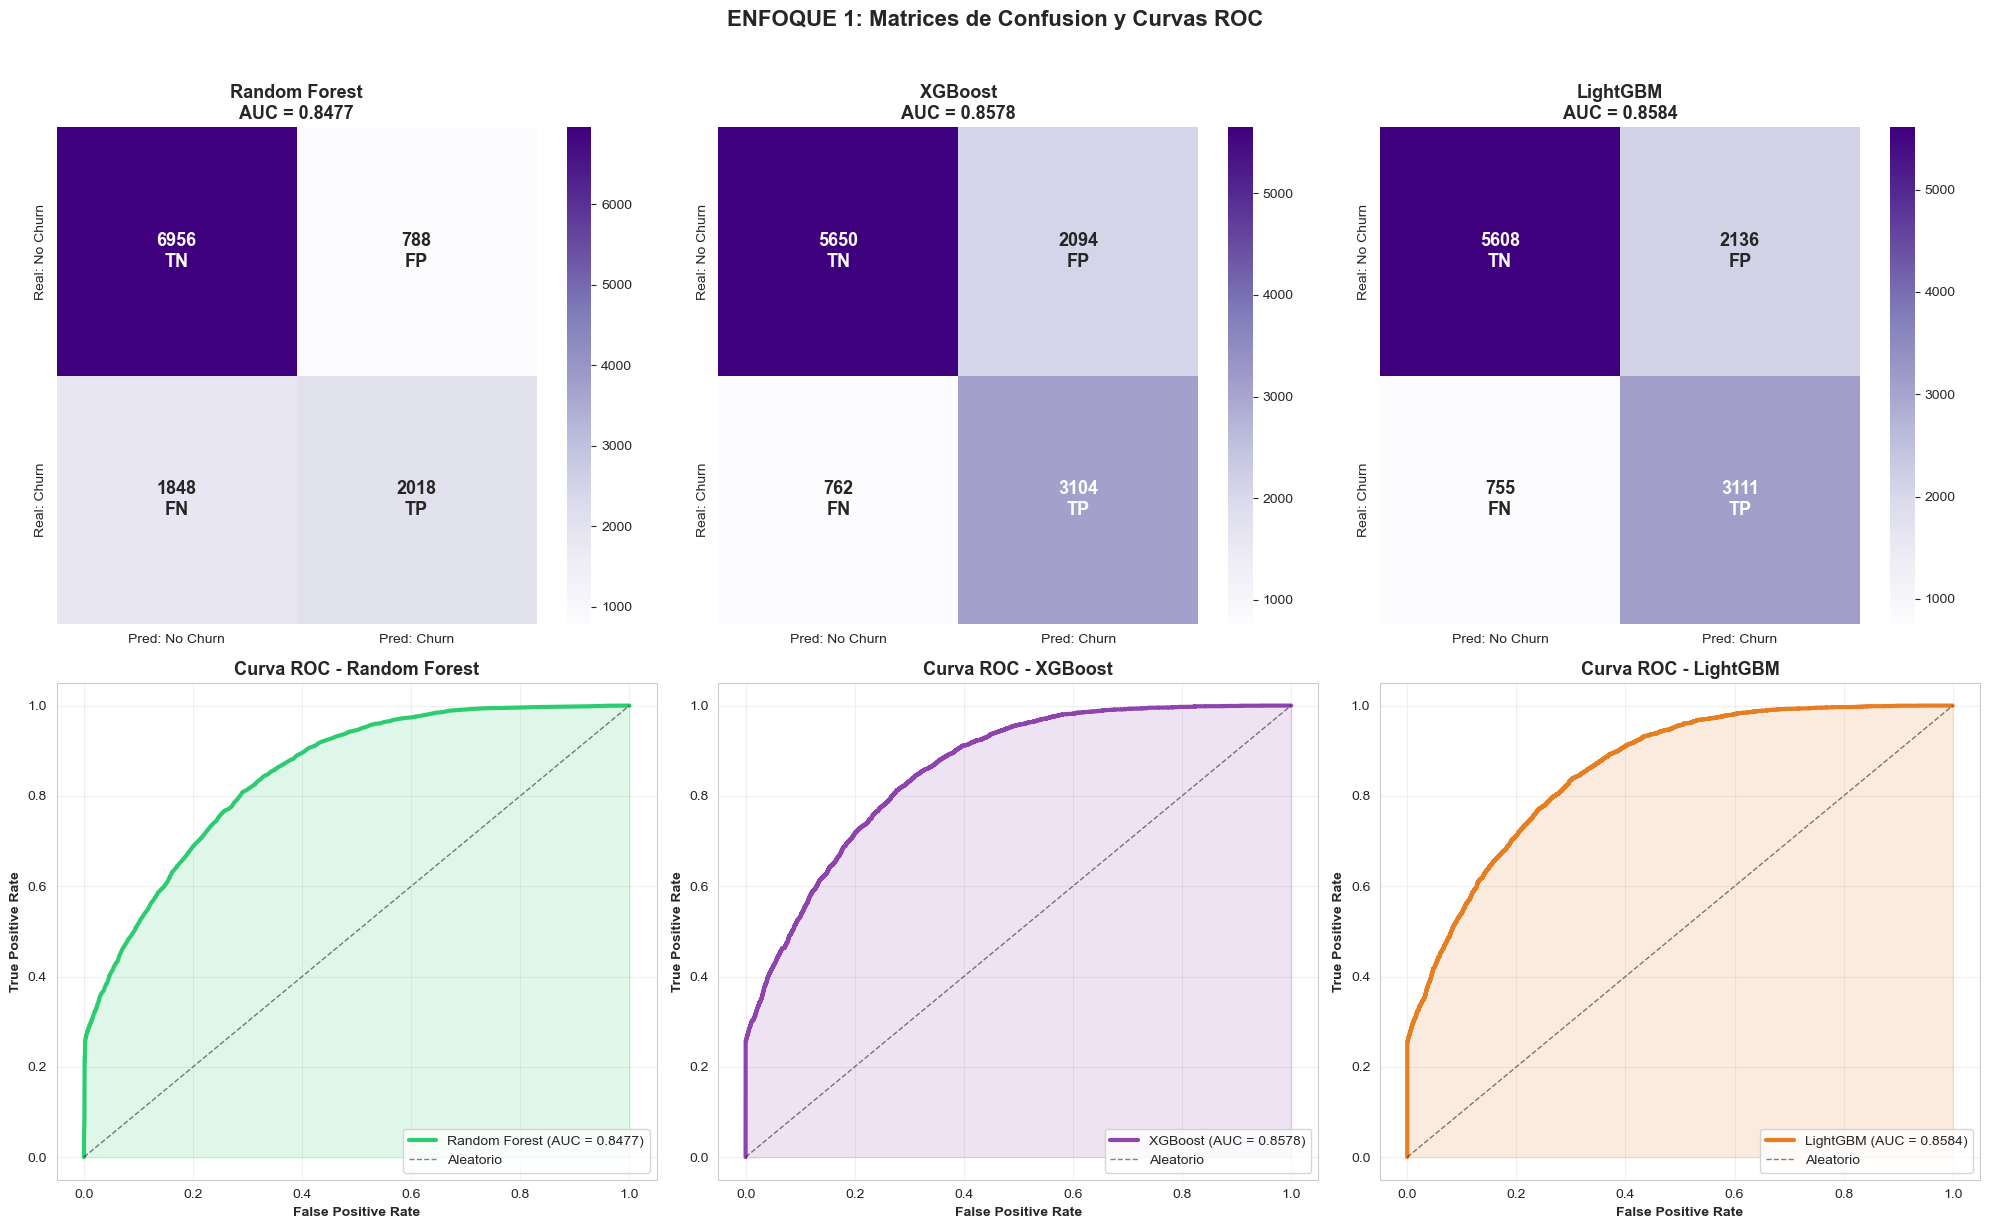

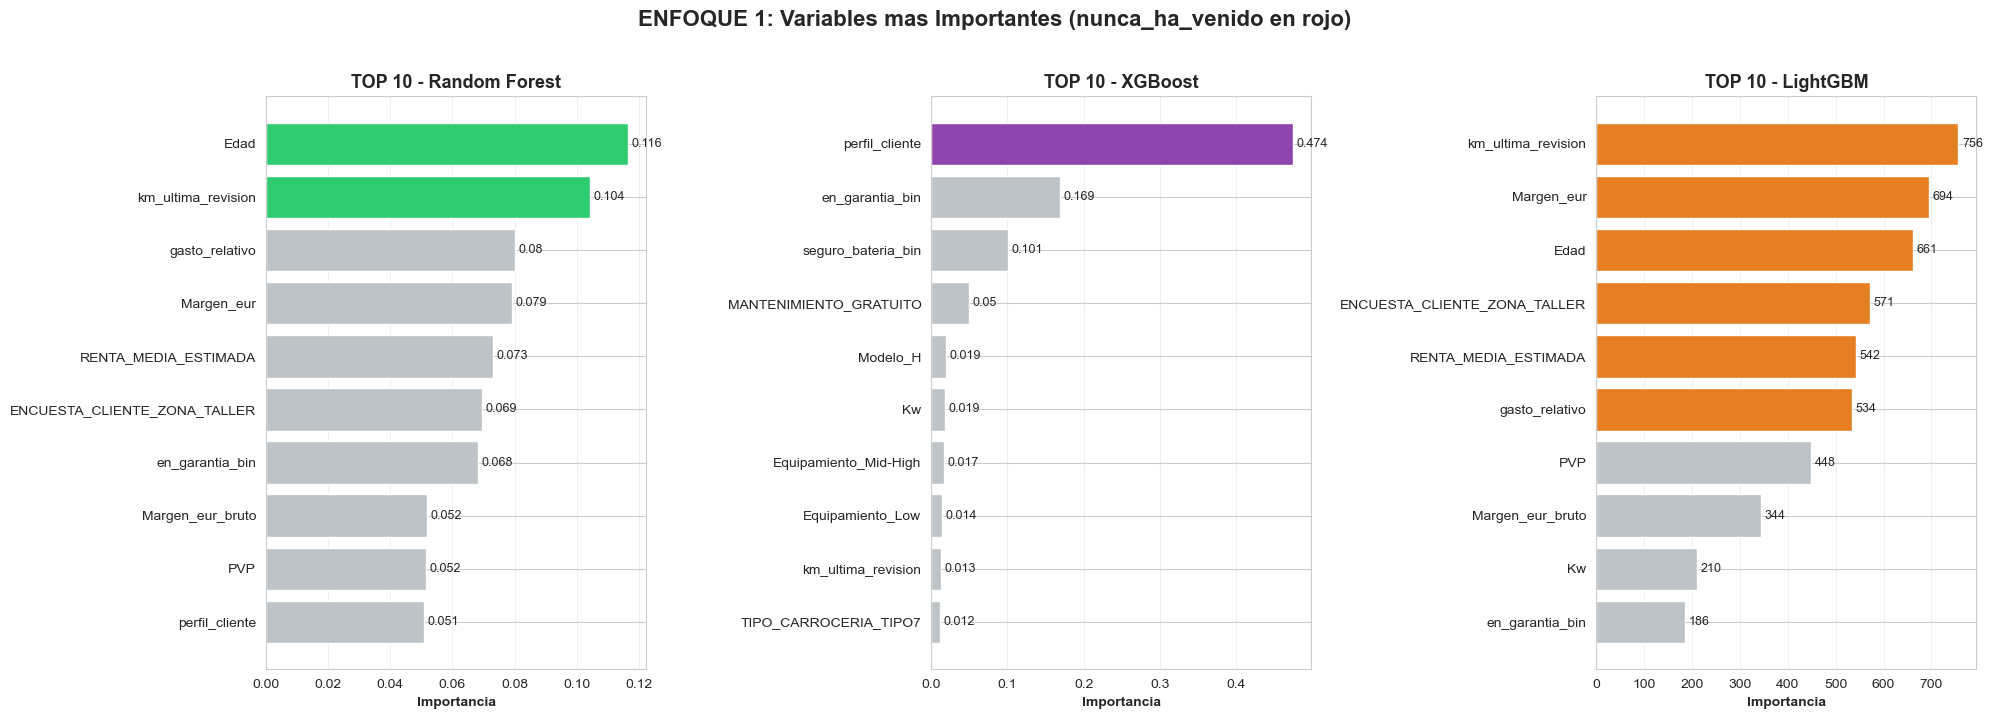

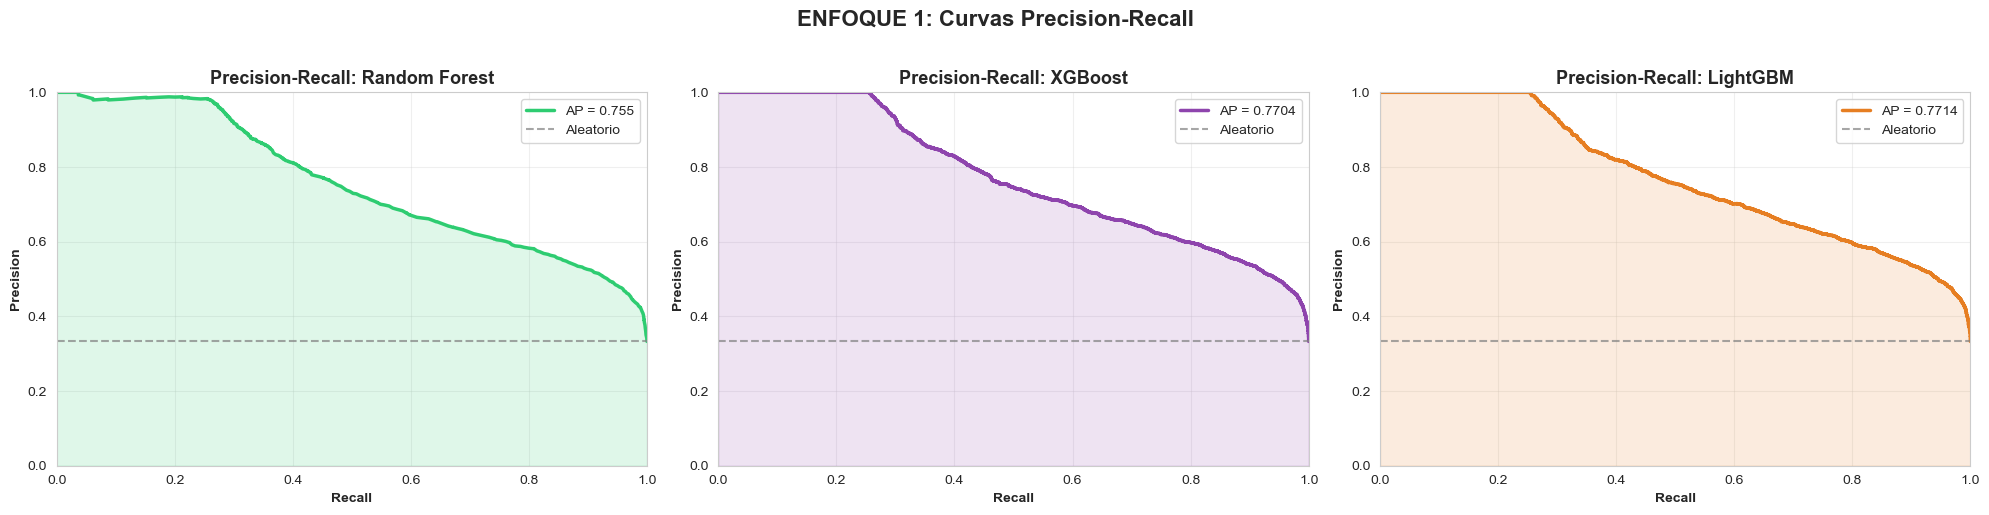

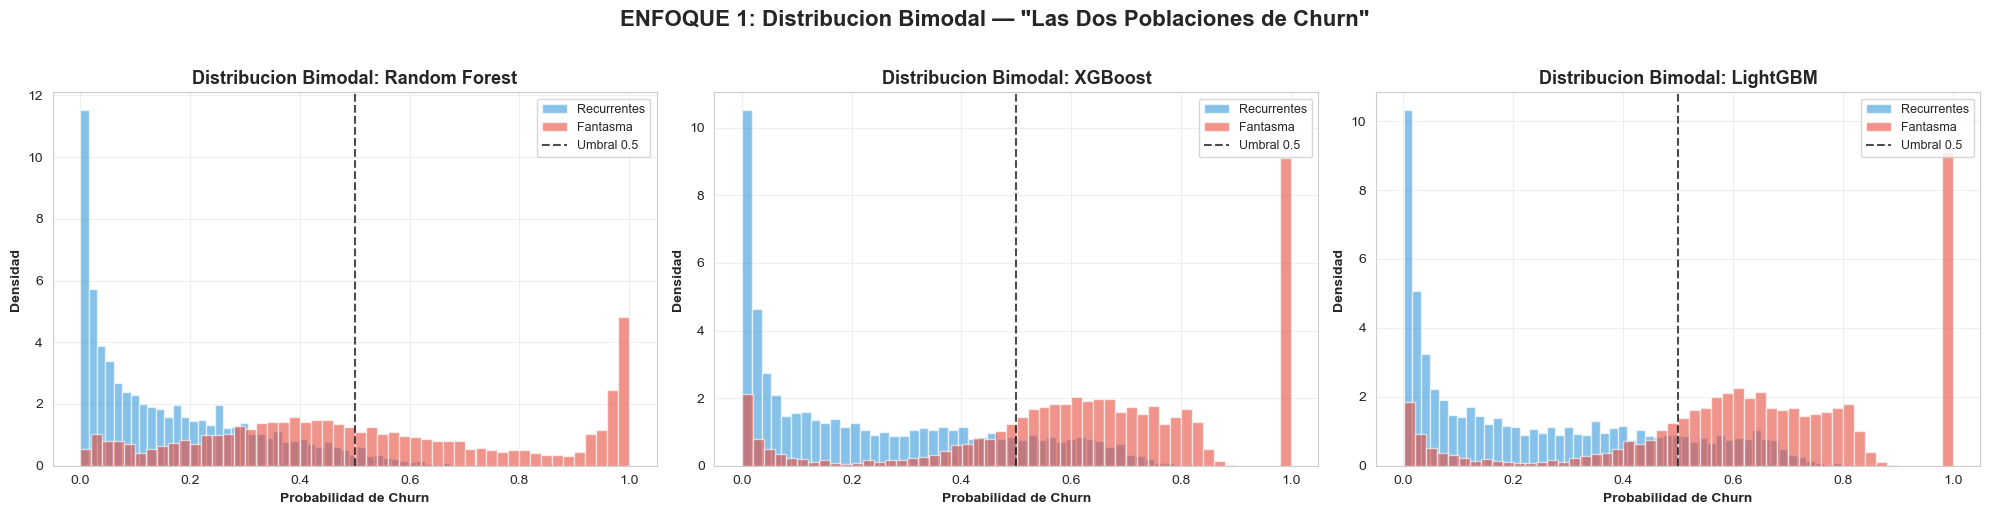

In [14]:
# =================================================================
# ENFOQUE 1: FEATURE ENGINEERING + CHURN CORREGIDO
# =================================================================
print('='*70)
print('ENFOQUE 1: FEATURE ENGINEERING (nunca_ha_venido)')
print('='*70)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score)
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import lightgbm as lgb

# Cargar DataMart original
dm_v1 = pd.read_csv('./Data/Datamart/datamart_ml_ready.csv')

# Obtener Revisiones y antiguedad_dias del df original
if 'df' in globals() and 'Revisiones' in df.columns:
    revisiones_v1 = df['Revisiones'].values
    antiguedad_v1 = df['antiguedad_dias'].values
    churn_bin_v1 = df['Churn_bin'].values
else:
    df_temp = pd.read_csv('./Data/DataLake/customer_data.csv')
    df_temp['Sales_Date'] = pd.to_datetime(df_temp['Sales_Date'], format='%d/%m/%Y', errors='coerce')
    fecha_corte = pd.to_datetime('31/12/2023', format='%d/%m/%Y')
    df_temp['antiguedad_dias'] = (fecha_corte - df_temp['Sales_Date']).dt.days.clip(lower=0)
    df_temp['Churn_bin'] = (df_temp['Churn_400'] == 'Y').astype(int)
    revisiones_v1 = df_temp['Revisiones'].values
    antiguedad_v1 = df_temp['antiguedad_dias'].values
    churn_bin_v1 = df_temp['Churn_bin'].values

# ---------------------------------------------------------------
# PASO 1: Crear variable nunca_ha_venido
# ---------------------------------------------------------------
print('')
print('PASO 1: Crear variable nunca_ha_venido')
print('-'*55)

dm_v1['nunca_ha_venido'] = (revisiones_v1 == 0).astype(int)

print('Variable creada: nunca_ha_venido')
print('   = 1 si Revisiones == 0 (cliente nunca visito el taller)')
print('   = 0 si Revisiones >= 1 (cliente con historial de taller)')
print('')
print('Distribucion:')
print('   Nunca vinieron:  ' + str((dm_v1['nunca_ha_venido']==1).sum()) + ' (' + str(round((dm_v1['nunca_ha_venido']==1).mean()*100,1)) + '%)')
print('   Con historial:   ' + str((dm_v1['nunca_ha_venido']==0).sum()) + ' (' + str(round((dm_v1['nunca_ha_venido']==0).mean()*100,1)) + '%)')

# ---------------------------------------------------------------
# PASO 2: Corregir target
# ---------------------------------------------------------------
print('')
print('PASO 2: Corregir target Churn_bin')
print('-'*55)

dm_v1['Churn_Final'] = (
    (churn_bin_v1 == 1) |
    ((revisiones_v1 == 0) & (antiguedad_v1 > 400))
).astype(int)

n_churn = (dm_v1['Churn_Final'] == 1).sum()
print('Churn_Final = 1:  ' + str(n_churn) + ' (' + str(round(n_churn/len(dm_v1)*100, 1)) + '%)')

# ---------------------------------------------------------------
# PASO 3: Preprocesamiento
# ---------------------------------------------------------------
print('')
print('PASO 3: Preprocesamiento')
print('-'*55)

vars_cat_v1 = ['Modelo', 'ZONA', 'FORMA_PAGO', 'TIPO_CARROCERIA', 'Equipamiento', 'Fuel', 'TRANSMISION_ID']
dm_v1_encoded = pd.get_dummies(dm_v1, columns=vars_cat_v1, drop_first=True, dtype=int)

cols_drop_v1 = [c for c in ['Churn_bin', 'Churn_Corregido', 'Churn_Final'] if c in dm_v1_encoded.columns]
cols_drop_v1 = [c for c in cols_drop_v1 if c != 'Churn_Final']
X_v1 = dm_v1_encoded.drop(columns=cols_drop_v1 + ['Churn_Final'])
y_v1 = dm_v1_encoded['Churn_Final']

if 'nunca_ha_venido' in X_v1.columns:
    print('OK: nunca_ha_venido incluida en features')

X_train_v1, X_test_v1, y_train_v1, y_test_v1 = train_test_split(
    X_v1, y_v1, test_size=0.2, random_state=42, stratify=y_v1
)

print('')
print('{:<12} {:>10} {:>10} {:>10}'.format('', 'Filas', 'Churn', '% Churn'))
print('-'*45)
print('{:<12} {:>10} {:>10} {:>9}%'.format('Train', str(len(X_train_v1)), str((y_train_v1==1).sum()), str(round((y_train_v1==1).mean()*100,1))))
print('{:<12} {:>10} {:>10} {:>9}%'.format('Test', str(len(X_test_v1)), str((y_test_v1==1).sum()), str(round((y_test_v1==1).mean()*100,1))))
print('-'*45)
print('Features: ' + str(X_train_v1.shape[1]) + ' (incluye nunca_ha_venido)')

# =========================================================================
# ENTRENAR 3 MODELOS
# =========================================================================
ratio_v1 = (y_train_v1 == 0).sum() / (y_train_v1 == 1).sum()

modelos_v1 = {}

# --- Random Forest ---
print('')
print('='*70)
print('1. RANDOM FOREST - ENFOQUE 1')
print('='*70)
rf_v1 = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
rf_v1.fit(X_train_v1, y_train_v1)
modelos_v1['Random Forest'] = {
    'model': rf_v1,
    'y_pred': rf_v1.predict(X_test_v1),
    'y_prob': rf_v1.predict_proba(X_test_v1)[:, 1],
    'importances': pd.Series(rf_v1.feature_importances_, index=X_train_v1.columns)
}
modelos_v1['Random Forest']['auc'] = roc_auc_score(y_test_v1, modelos_v1['Random Forest']['y_prob'])
print('AUC-ROC: ' + str(round(modelos_v1['Random Forest']['auc'], 4)))
print(classification_report(y_test_v1, modelos_v1['Random Forest']['y_pred'], target_names=['No Churn', 'Churn']))

# --- XGBoost ---
print('='*70)
print('2. XGBOOST - ENFOQUE 1')
print('='*70)
xgb_v1 = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                        scale_pos_weight=ratio_v1, random_state=42,
                        eval_metric='logloss', n_jobs=-1)
xgb_v1.fit(X_train_v1, y_train_v1)
modelos_v1['XGBoost'] = {
    'model': xgb_v1,
    'y_pred': xgb_v1.predict(X_test_v1),
    'y_prob': xgb_v1.predict_proba(X_test_v1)[:, 1],
    'importances': pd.Series(xgb_v1.feature_importances_, index=X_train_v1.columns)
}
modelos_v1['XGBoost']['auc'] = roc_auc_score(y_test_v1, modelos_v1['XGBoost']['y_prob'])
print('AUC-ROC: ' + str(round(modelos_v1['XGBoost']['auc'], 4)))
print(classification_report(y_test_v1, modelos_v1['XGBoost']['y_pred'], target_names=['No Churn', 'Churn']))

# --- LightGBM ---
print('='*70)
print('3. LIGHTGBM - ENFOQUE 1')
print('='*70)
lgb_v1 = lgb.LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                              scale_pos_weight=ratio_v1, random_state=42,
                              n_jobs=-1, verbose=-1)
lgb_v1.fit(X_train_v1, y_train_v1)
modelos_v1['LightGBM'] = {
    'model': lgb_v1,
    'y_pred': lgb_v1.predict(X_test_v1),
    'y_prob': lgb_v1.predict_proba(X_test_v1)[:, 1],
    'importances': pd.Series(lgb_v1.feature_importances_, index=X_train_v1.columns)
}
modelos_v1['LightGBM']['auc'] = roc_auc_score(y_test_v1, modelos_v1['LightGBM']['y_prob'])
print('AUC-ROC: ' + str(round(modelos_v1['LightGBM']['auc'], 4)))
print(classification_report(y_test_v1, modelos_v1['LightGBM']['y_pred'], target_names=['No Churn', 'Churn']))

# =========================================================================
# COMPARATIVA DE MODELOS
# =========================================================================
print('')
print('='*70)
print('COMPARATIVA: RF vs XGBoost vs LightGBM (Enfoque 1)')
print('='*70)
print('')
print('{:<22} {:>15} {:>15} {:>15}'.format('Metrica', 'Random Forest', 'XGBoost', 'LightGBM'))
print('='*70)
for nombre, datos in modelos_v1.items():
    cm = confusion_matrix(y_test_v1, datos['y_pred'])
    tn, fp, fn, tp = cm.ravel()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    datos['precision'] = prec
    datos['recall'] = rec
    datos['f1'] = f1

print('{:<22} {:>14.1f}% {:>14.1f}% {:>14.1f}%'.format('Precision (Churn)',
    modelos_v1['Random Forest']['precision']*100,
    modelos_v1['XGBoost']['precision']*100,
    modelos_v1['LightGBM']['precision']*100))
print('{:<22} {:>14.1f}% {:>14.1f}% {:>14.1f}%'.format('Recall (Churn)',
    modelos_v1['Random Forest']['recall']*100,
    modelos_v1['XGBoost']['recall']*100,
    modelos_v1['LightGBM']['recall']*100))
print('{:<22} {:>14.1f}% {:>14.1f}% {:>14.1f}%'.format('F1-Score (Churn)',
    modelos_v1['Random Forest']['f1']*100,
    modelos_v1['XGBoost']['f1']*100,
    modelos_v1['LightGBM']['f1']*100))
print('{:<22} {:>14.4f}  {:>14.4f}  {:>14.4f}'.format('AUC-ROC',
    modelos_v1['Random Forest']['auc'],
    modelos_v1['XGBoost']['auc'],
    modelos_v1['LightGBM']['auc']))
print('='*70)

# =========================================================================
# VISUALIZACIONES: Matrices de Confusion + Curvas ROC (3 modelos)
# =========================================================================
colores = {'Random Forest': '#2ecc71', 'XGBoost': '#8e44ad', 'LightGBM': '#e67e22'}

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

for idx, (nombre, datos) in enumerate(modelos_v1.items()):
    color = colores[nombre]
    cm = confusion_matrix(y_test_v1, datos['y_pred'])
    tn, fp, fn, tp = cm.ravel()

    # Fila 1: Matrices de Confusion
    labels = np.array([[str(tn) + '\nTN', str(fp) + '\nFP'],
                       [str(fn) + '\nFN', str(tp) + '\nTP']])
    sns.heatmap(cm, annot=labels, fmt='', cmap='Purples', ax=axes[0, idx],
                xticklabels=['Pred: No Churn', 'Pred: Churn'],
                yticklabels=['Real: No Churn', 'Real: Churn'],
                annot_kws={'size': 13, 'weight': 'bold'})
    axes[0, idx].set_title(nombre + '\nAUC = ' + str(round(datos['auc'], 4)),
                           fontsize=13, fontweight='bold')

    # Fila 2: Curvas ROC
    fpr, tpr, _ = roc_curve(y_test_v1, datos['y_prob'])
    axes[1, idx].plot(fpr, tpr, color=color, linewidth=3,
                      label=nombre + ' (AUC = ' + str(round(datos['auc'], 4)) + ')')
    axes[1, idx].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Aleatorio')
    axes[1, idx].fill_between(fpr, tpr, alpha=0.15, color=color)
    axes[1, idx].set_xlabel('False Positive Rate', fontweight='bold')
    axes[1, idx].set_ylabel('True Positive Rate', fontweight='bold')
    axes[1, idx].set_title('Curva ROC - ' + nombre, fontsize=13, fontweight='bold')
    axes[1, idx].legend(loc='lower right')
    axes[1, idx].grid(True, alpha=0.3)

plt.suptitle('ENFOQUE 1: Matrices de Confusion y Curvas ROC', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# =========================================================================
# TOP 10 VARIABLES MAS IMPORTANTES (3 modelos)
# =========================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for idx, (nombre, datos) in enumerate(modelos_v1.items()):
    color = colores[nombre]
    top10 = datos['importances'].sort_values(ascending=True).tail(10)

    bar_colors = []
    for var in top10.index:
        if var == 'nunca_ha_venido':
            bar_colors.append('#e74c3c')
        elif top10[var] >= top10.values[-1] * 0.7:
            bar_colors.append(color)
        else:
            bar_colors.append('#bdc3c7')

    axes[idx].barh(top10.index, top10.values, color=bar_colors, edgecolor='white', linewidth=1)
    axes[idx].set_xlabel('Importancia', fontweight='bold')
    axes[idx].set_title('TOP 10 - ' + nombre, fontsize=13, fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='x')
    for var, val in top10.items():
        axes[idx].text(val + max(top10.values)*0.01, var, str(round(val, 3)), va='center', fontsize=9)

plt.suptitle('ENFOQUE 1: Variables mas Importantes (nunca_ha_venido en rojo)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# =========================================================================
# CURVAS PRECISION-RECALL (3 modelos)
# =========================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
baseline_pr = (y_test_v1 == 1).sum() / len(y_test_v1)

for idx, (nombre, datos) in enumerate(modelos_v1.items()):
    color = colores[nombre]
    precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test_v1, datos['y_prob'])
    ap = average_precision_score(y_test_v1, datos['y_prob'])

    axes[idx].plot(recall_vals, precision_vals, color=color, linewidth=2.5,
                   label='AP = ' + str(round(ap, 4)))
    axes[idx].axhline(y=baseline_pr, color='gray', linestyle='--', alpha=0.7, label='Aleatorio')
    axes[idx].fill_between(recall_vals, precision_vals, alpha=0.15, color=color)
    axes[idx].set_xlabel('Recall', fontweight='bold')
    axes[idx].set_ylabel('Precision', fontweight='bold')
    axes[idx].set_title('Precision-Recall: ' + nombre, fontsize=13, fontweight='bold')
    axes[idx].legend(loc='upper right')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xlim([0, 1])
    axes[idx].set_ylim([0, 1])

plt.suptitle('ENFOQUE 1: Curvas Precision-Recall', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# =========================================================================
# DISTRIBUCION BIMODAL: "Las Jorobas del Camello" (3 modelos)
# =========================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for idx, (nombre, datos) in enumerate(modelos_v1.items()):
    color = colores[nombre]

    # Separar probabilidades por perfil
    ghost_mask = X_test_v1['perfil_cliente'].values == 1
    recur_mask = X_test_v1['perfil_cliente'].values == 0

    ghost_probs = datos['y_prob'][ghost_mask]
    recur_probs = datos['y_prob'][recur_mask]

    axes[idx].hist(recur_probs, bins=50, alpha=0.6, color='#3498db', label='Recurrentes', density=True)
    axes[idx].hist(ghost_probs, bins=50, alpha=0.6, color='#e74c3c', label='Fantasma', density=True)
    axes[idx].axvline(x=0.5, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label='Umbral 0.5')
    axes[idx].set_xlabel('Probabilidad de Churn', fontweight='bold')
    axes[idx].set_ylabel('Densidad', fontweight='bold')
    axes[idx].set_title('Distribucion Bimodal: ' + nombre, fontsize=13, fontweight='bold')
    axes[idx].legend(fontsize=9)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('ENFOQUE 1: Distribucion Bimodal — "Las Dos Poblaciones de Churn"',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
---

# Enfoque 2: Eliminacion del Leakage Logico

## Diagnostico del problema

El Enfoque 1 obtiene AUC-ROC muy alto porque el **target esta definido por las propias features**:

```
Churn_Final = 1 si:
  - Churn_bin == 1                                    <- usa dias desde ultima visita
  - (Revisiones == 0) AND (antiguedad_dias > 400)     <- usa Revisiones + antiguedad_dias
```

El modelo aprende la regla: `Revisiones=0 + antiguedad_dias>400 -> Churn=1`.
Esto **no es overfitting**: es que las features CONTIENEN la respuesta.

## Solucion: Eliminar las variables que definen el target

| Accion | Razon |
|--------|-------|
| **Eliminar `Revisiones`** | Define directamente si el cliente es "ghost" (0 revisiones) |
| **Eliminar `antiguedad_dias`** | Define el umbral de 400 dias para clasificar como churn |
| **Crear `perfil_cliente`** | Variable binaria (0=recurrente, 1=ghost) que captura contexto sin codificar la regla |

### Features finales (sin leakage)

| Tipo | Variables | Descripcion |
|------|-----------|-------------|
| **Numericas (9)** | `km_ultima_revision`, `PVP`, `Edad`, `RENTA_MEDIA_ESTIMADA`, `gasto_relativo`, `Kw`, `Margen_eur_bruto`, `Margen_eur`, `ENCUESTA_CLIENTE_ZONA_TALLER` | Perfil economico y vehiculo |
| **Binarias (5)** | `tiene_queja`, `en_garantia_bin`, `perfil_cliente`, `MANTENIMIENTO_GRATUITO`, `seguro_bateria_bin` | Indicadores de comportamiento |
| **Categoricas (7)** | `Modelo`, `ZONA`, `FORMA_PAGO`, `TIPO_CARROCERIA`, `Equipamiento`, `Fuel`, `TRANSMISION_ID` | Vehiculo y zona |

### Modelos entrenados

Se comparan **3 algoritmos**: Random Forest, XGBoost (regularizado) y LightGBM, cada uno con:
- Validacion cruzada (Stratified K-Fold, 5 folds)
- Curva AUC-ROC y matriz de confusion
- Curva Precision-Recall
- Distribucion bimodal de probabilidades
- Top de variables mas importantes

In [15]:
# =================================================================
# ENFOQUE 2: ELIMINACION DEL LEAKAGE LOGICO
# =================================================================
print('='*70)
print('ENFOQUE 2: ELIMINACION DEL LEAKAGE LOGICO (SIN LEAKAGE)')
print('='*70)

# Cargar DataMart original
dm_v4 = pd.read_csv('./Data/Datamart/datamart_ml_ready.csv')

print('')
print('FEATURES INCLUIDAS (sin leakage):')
print('-'*55)
print('')
print('Numéricas (9):')
print('  km_ultima_revision, PVP, Edad, RENTA_MEDIA_ESTIMADA,')
print('  gasto_relativo, Kw, Margen_eur_bruto, Margen_eur,')
print('  ENCUESTA_CLIENTE_ZONA_TALLER')
print('')
print('Binarias (5):')
print('  tiene_queja, en_garantia_bin, perfil_cliente,')
print('  MANTENIMIENTO_GRATUITO, seguro_bateria_bin')
print('')
print('Categóricas (6):')
print('  Modelo, ZONA, FORMA_PAGO, TIPO_CARROCERIA,')
print('  Equipamiento, Fuel, TRANSMISION_ID')

# ---------------------------------------------------------------
# PASO 1: Crear target Churn_Final
# ---------------------------------------------------------------
print('')
print('PASO 1: Crear target Churn_Final')
print('-'*55)

# Necesitamos antiguedad_dias y Revisiones SOLO para crear el target
# (pero NO estarán en las features)
from datetime import datetime
df_temp = pd.read_csv('./Data/DataLake/customer_data.csv')
df_temp['Sales_Date'] = pd.to_datetime(df_temp['Sales_Date'], format='%d/%m/%Y', errors='coerce')
fecha_corte = pd.to_datetime('31/12/2023', format='%d/%m/%Y')
df_temp['antiguedad_dias'] = (fecha_corte - df_temp['Sales_Date']).dt.days.clip(lower=0)

# Merge para obtener antiguedad_dias
dm_v4 = dm_v4.merge(
    df_temp[['CODE', 'Revisiones', 'antiguedad_dias']],
    left_on=dm_v4.index,
    right_on=df_temp.index,
    how='left'
)

# Crear Churn_Final
dm_v4['Churn_Final'] = (
    (dm_v4['Churn_bin'] == 1) |
    ((dm_v4['Revisiones'] == 0) & (dm_v4['antiguedad_dias'] > 400))
).astype(int)

n_churn = (dm_v4['Churn_Final'] == 1).sum()
print('Churn_Final = 1:  ' + str(n_churn) + ' (' + str(round(n_churn/len(dm_v4)*100, 1)) + '%)')

# ELIMINAR Revisiones y antiguedad_dias INMEDIATAMENTE
dm_v4 = dm_v4.drop(columns=['Revisiones', 'antiguedad_dias', 'CODE'])

# ---------------------------------------------------------------
# PASO 2: One-hot encoding de categóricas
# ---------------------------------------------------------------
print('')
print('PASO 2: One-hot encoding')
print('-'*55)

vars_cat = ['Modelo', 'ZONA', 'FORMA_PAGO', 'TIPO_CARROCERIA',
            'Equipamiento', 'Fuel', 'TRANSMISION_ID']

print('Categóricas a expandir:')
for var in vars_cat:
    n_cat = dm_v4[var].nunique()
    n_dummies = n_cat - 1
    print(f'   {var:20s}: {n_cat} categorías → {n_dummies} dummies')

dm_v4_encoded = pd.get_dummies(dm_v4, columns=vars_cat, drop_first=True, dtype=int)

# ---------------------------------------------------------------
# PASO 3: Separar X e y
# ---------------------------------------------------------------
print('')
print('PASO 3: Separar X e y')
print('-'*55)

# Eliminar targets
cols_to_drop = [c for c in ['Churn_bin', 'Churn_Corregido', 'Churn_Final'] if c in dm_v4_encoded.columns]
cols_to_drop.remove('Churn_Final')  # Mantener solo Churn_Final como target

X_v4 = dm_v4_encoded.drop(columns=cols_to_drop + ['Churn_Final'])
y_v4 = dm_v4_encoded['Churn_Final']

print('Features finales (' + str(X_v4.shape[1]) + '):')
for i, col in enumerate(X_v4.columns, 1):
    print('   ' + str(i) + '. ' + col)

print('')
print('VERIFICACIÓN ANTI-LEAKAGE:')
print('-'*55)
print('Variables PROHIBIDAS que NO deben estar en X:')
prohibidas = ['Revisiones', 'antiguedad_dias', 'DAYS_LAST_SERVICE', 'Km_medio_por_revision']
for var in prohibidas:
    if var in X_v4.columns:
        print(f'   ✗ ERROR: {var} está en features!')
    else:
        print(f'   ✓ {var} NO está en features (correcto)')

# ---------------------------------------------------------------
# PASO 4: Train/Test Split estratificado
# ---------------------------------------------------------------
print('')
print('PASO 4: Train/Test Split (80/20)')
print('-'*55)

X_train_v4, X_test_v4, y_train_v4, y_test_v4 = train_test_split(
    X_v4, y_v4,
    test_size=0.2,
    random_state=42,
    stratify=y_v4
)

print('')
print('{:<12} {:>10} {:>10} {:>10}'.format('', 'Filas', 'Churn', '% Churn'))
print('-'*45)
print('{:<12} {:>10} {:>10} {:>9}%'.format('Train', str(len(X_train_v4)), str((y_train_v4==1).sum()), str(round((y_train_v4==1).mean()*100,1))))
print('{:<12} {:>10} {:>10} {:>9}%'.format('Test', str(len(X_test_v4)), str((y_test_v4==1).sum()), str(round((y_test_v4==1).mean()*100,1))))
print('-'*45)
print('')
print('El modelo debe predecir usando PERFIL DEL CLIENTE + características del vehículo.')
print('NO tiene acceso a: Revisiones, antiguedad_dias, DAYS_LAST_SERVICE.')

ENFOQUE 2: ELIMINACION DEL LEAKAGE LOGICO (SIN LEAKAGE)

FEATURES INCLUIDAS (sin leakage):
-------------------------------------------------------

Numéricas (9):
  km_ultima_revision, PVP, Edad, RENTA_MEDIA_ESTIMADA,
  gasto_relativo, Kw, Margen_eur_bruto, Margen_eur,
  ENCUESTA_CLIENTE_ZONA_TALLER

Binarias (5):
  tiene_queja, en_garantia_bin, perfil_cliente,
  MANTENIMIENTO_GRATUITO, seguro_bateria_bin

Categóricas (6):
  Modelo, ZONA, FORMA_PAGO, TIPO_CARROCERIA,
  Equipamiento, Fuel, TRANSMISION_ID

PASO 1: Crear target Churn_Final
-------------------------------------------------------
Churn_Final = 1:  19329 (33.3%)

PASO 2: One-hot encoding
-------------------------------------------------------
Categóricas a expandir:
   Modelo              : 11 categorías → 10 dummies
   ZONA                : 4 categorías → 3 dummies
   FORMA_PAGO          : 4 categorías → 3 dummies
   TIPO_CARROCERIA     : 8 categorías → 7 dummies
   Equipamiento        : 4 categorías → 3 dummies
   Fuel    

ENFOQUE 2: ENTRENAMIENTO DE 3 MODELOS (SIN LEAKAGE)
Ratio clases (No Churn / Churn): 2.0

VALIDACION CRUZADA - STRATIFIED K-FOLD (5 FOLDS)
Fold 1:  RF=0.8425  XGB=0.8495  LGB=0.8495
Fold 2:  RF=0.8418  XGB=0.847  LGB=0.8479
Fold 3:  RF=0.8416  XGB=0.8455  LGB=0.846
Fold 4:  RF=0.8592  XGB=0.8628  LGB=0.8631
Fold 5:  RF=0.8481  XGB=0.8522  LGB=0.8523

RESUMEN VALIDACION CRUZADA:
-------------------------------------------------------
Random Forest   AUC = 0.8467 +/- 0.0067
XGBoost         AUC = 0.8514 +/- 0.0061
LightGBM        AUC = 0.8518 +/- 0.0061

1. RANDOM FOREST - ENFOQUE 2 (sin leakage)
AUC-ROC: 0.8487
              precision    recall  f1-score   support

    No Churn       0.79      0.90      0.84      7744
       Churn       0.72      0.52      0.61      3866

    accuracy                           0.77     11610
   macro avg       0.76      0.71      0.72     11610
weighted avg       0.77      0.77      0.76     11610

2. XGBOOST REGULARIZADO - ENFOQUE 2 (sin leakage)
AUC-RO

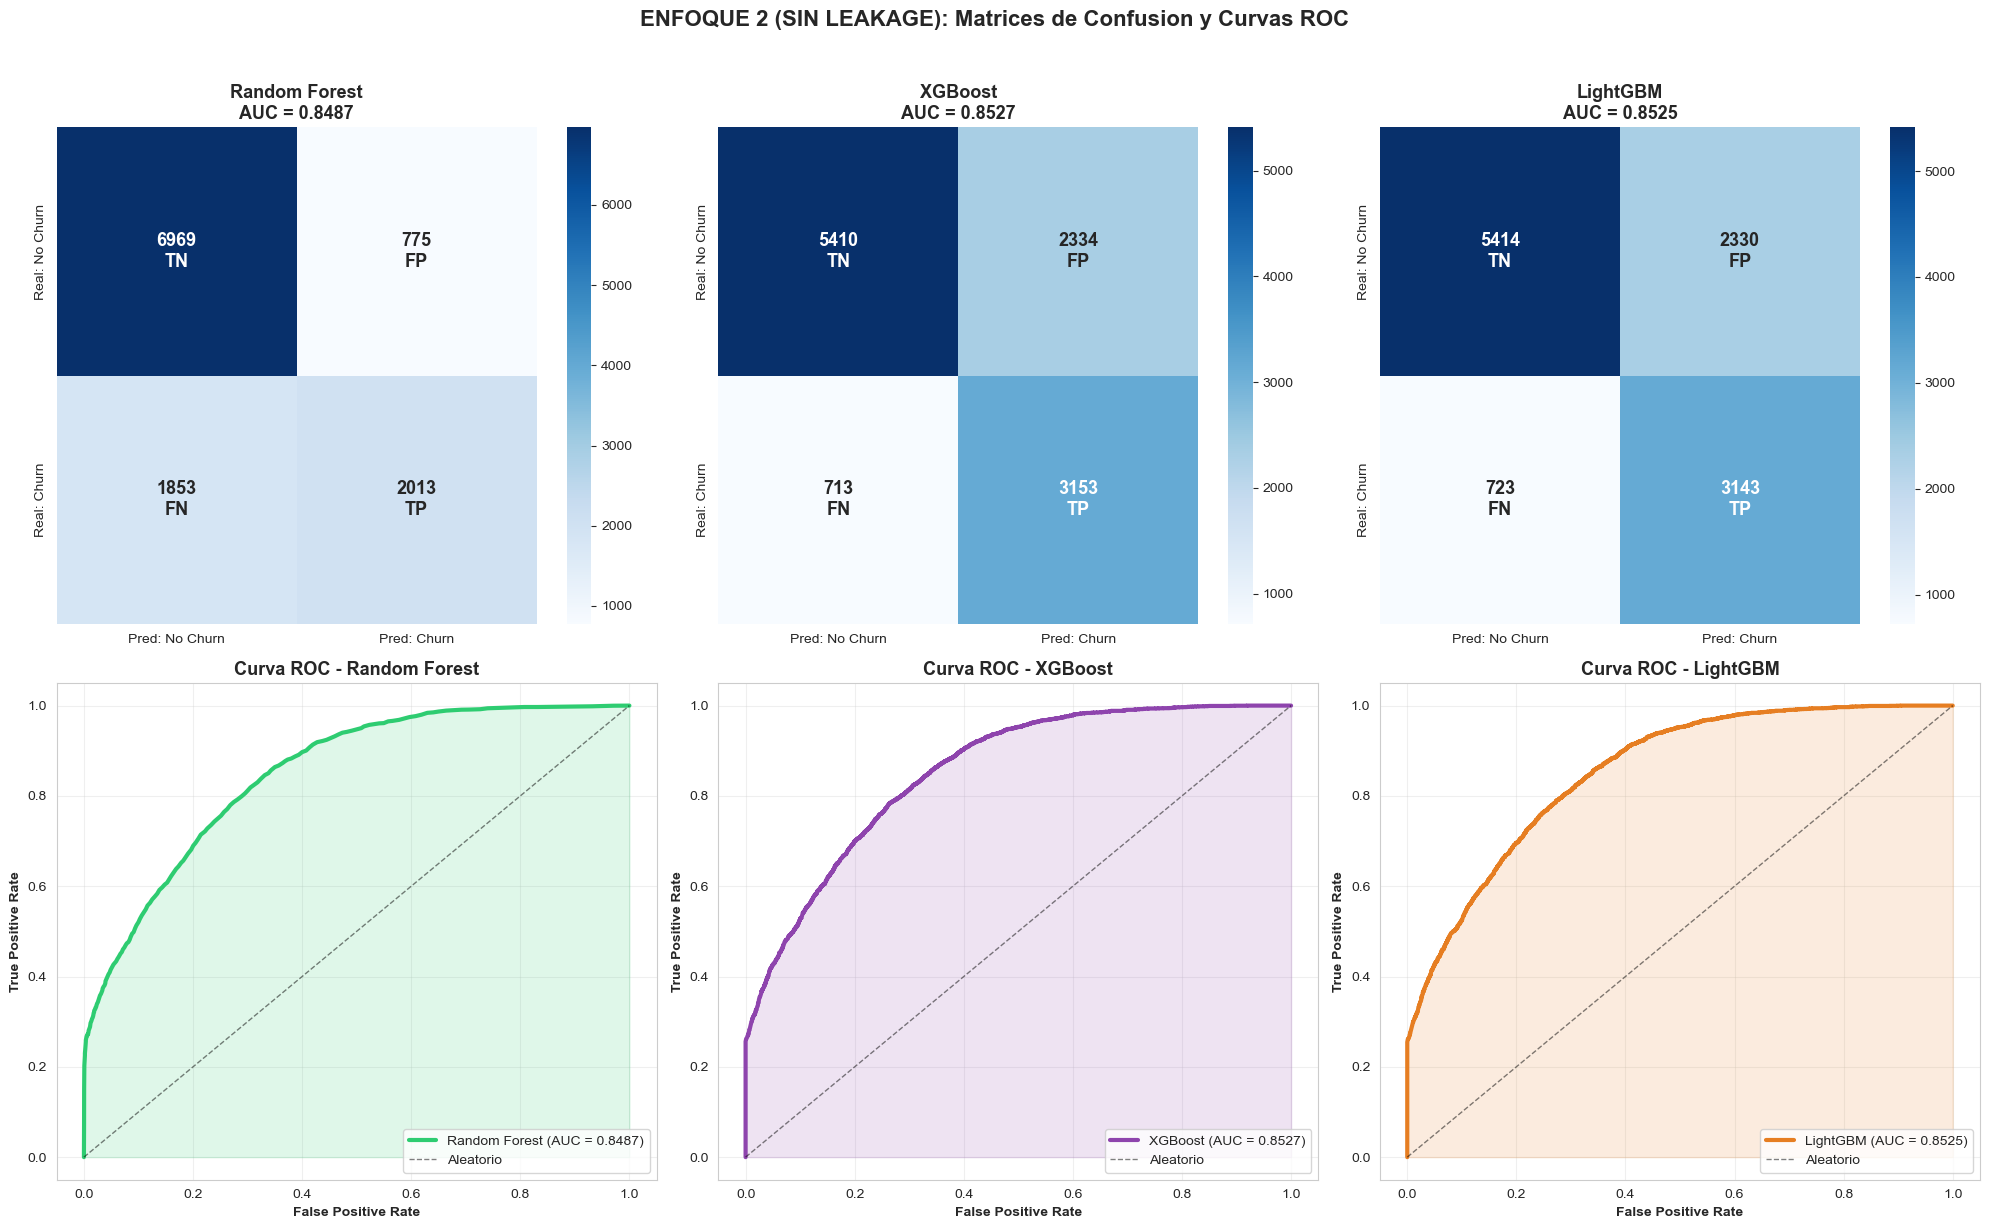

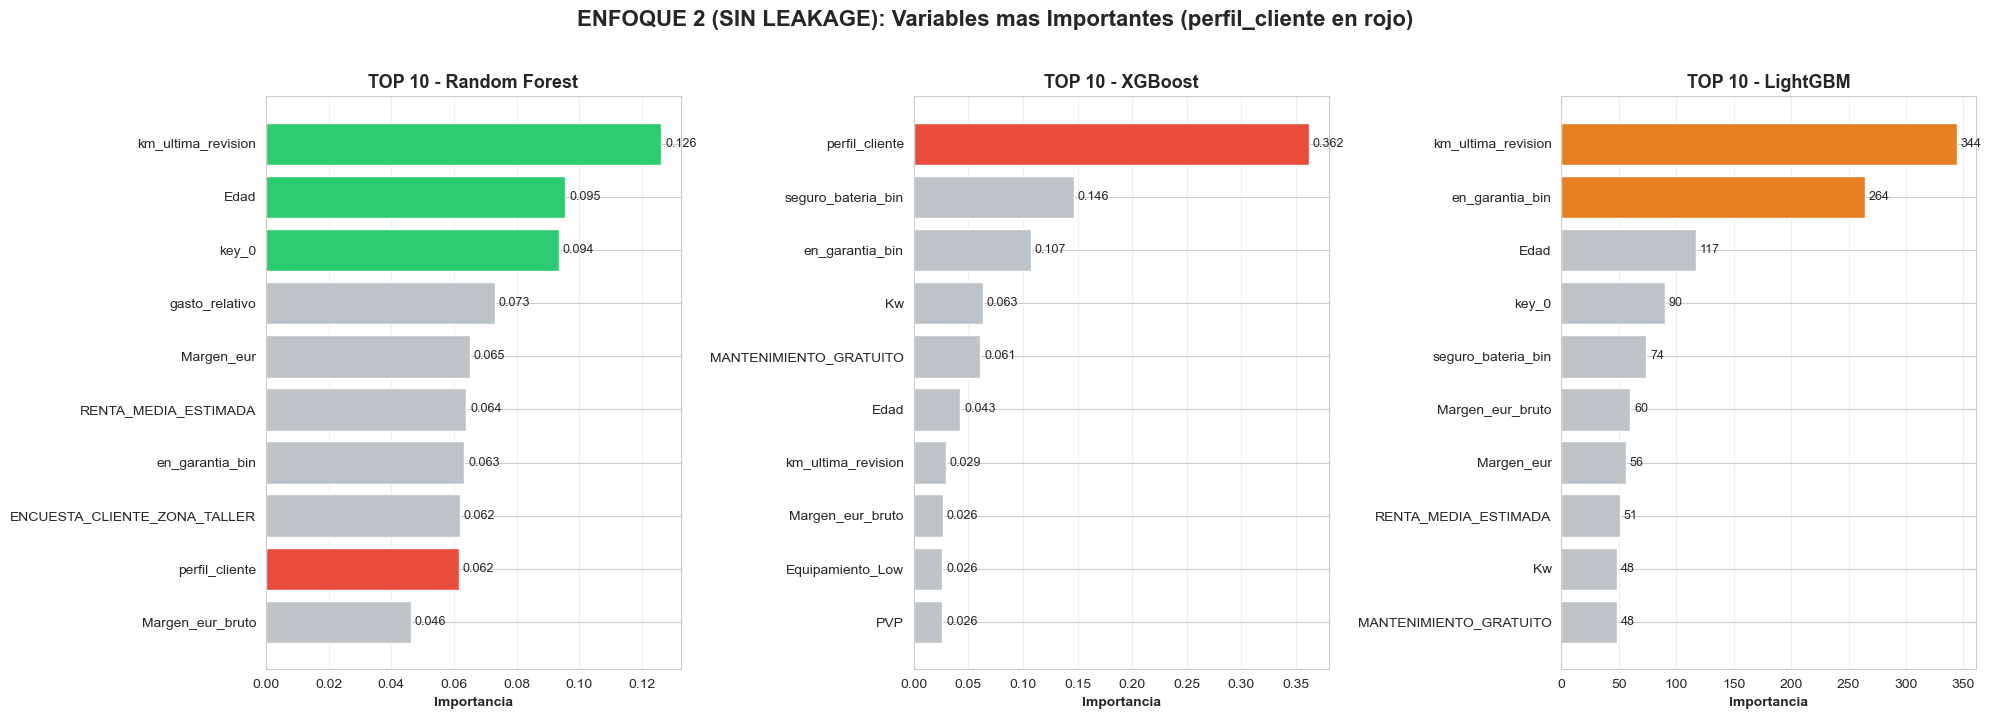

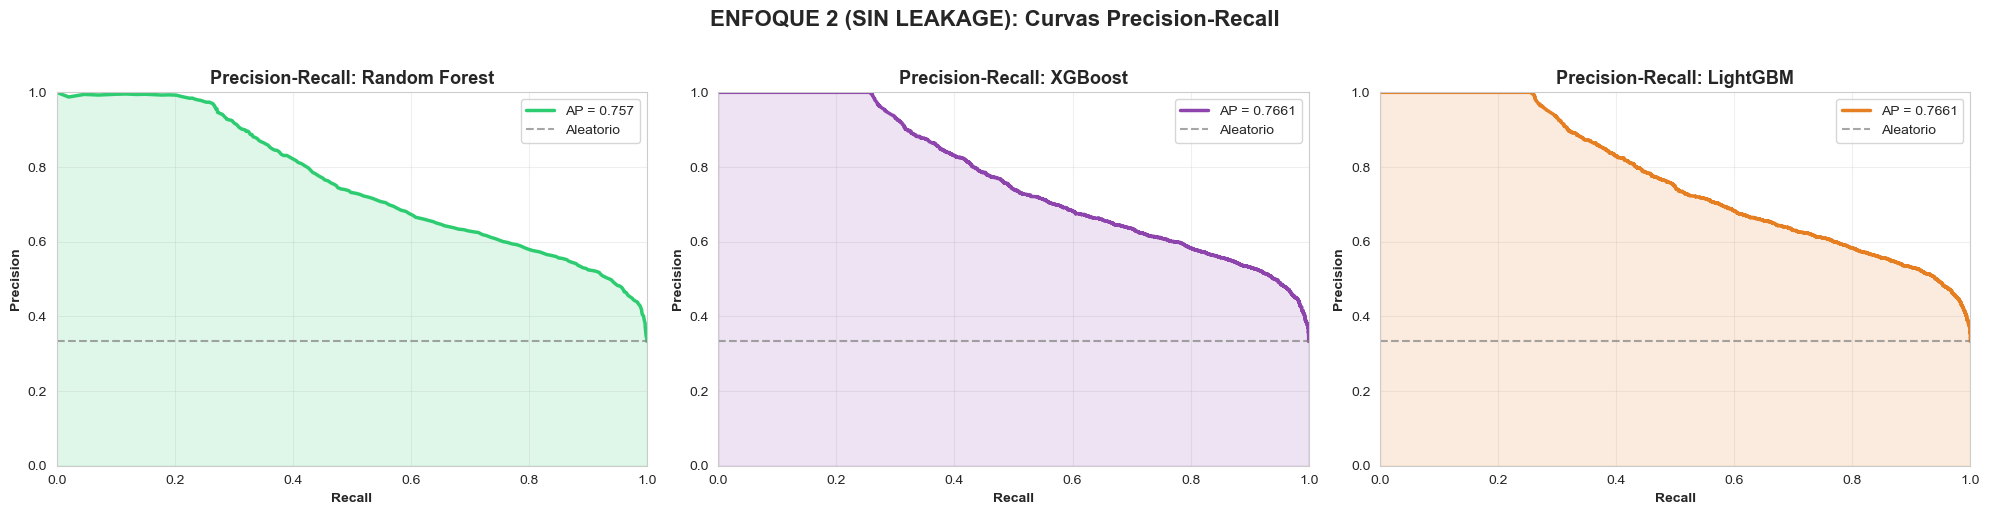

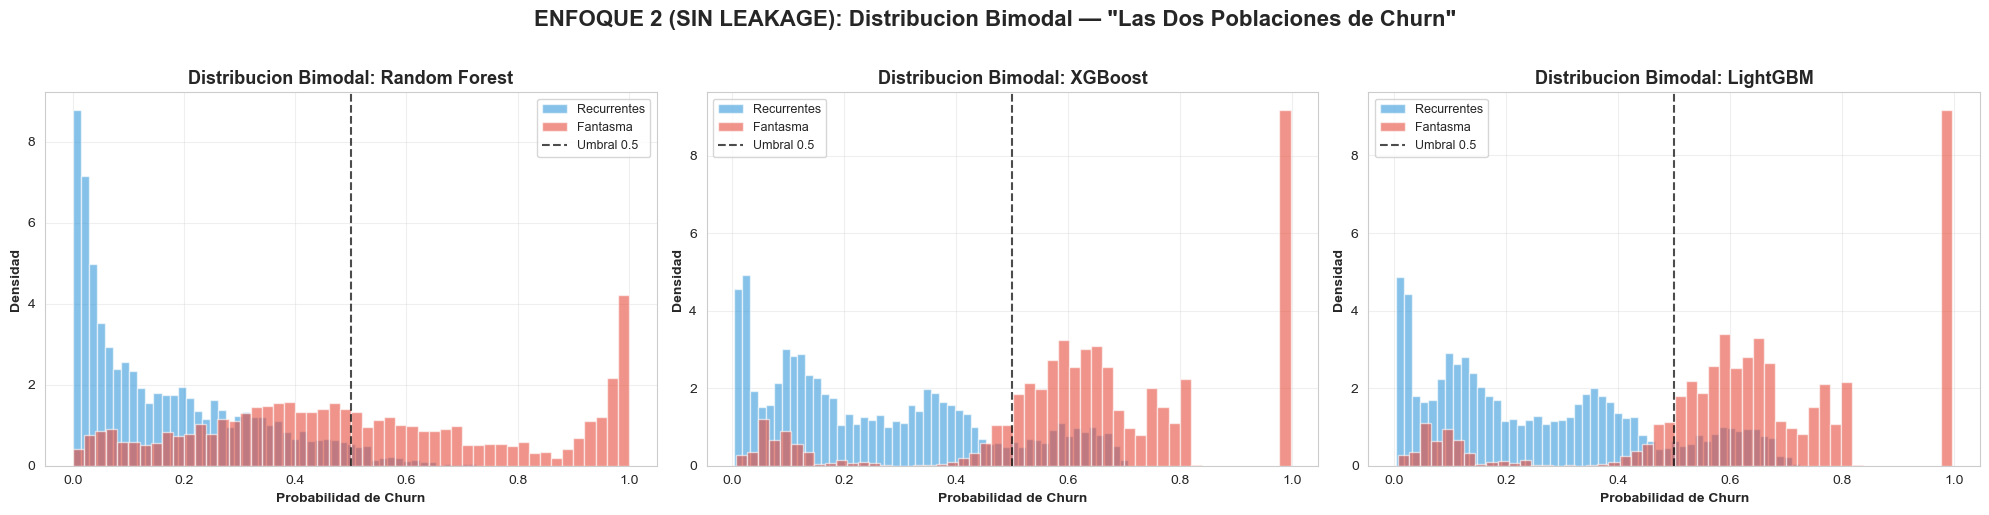


Mejor modelo: XGBoost (AUC = 0.8527)
Modelo guardado para prediccion en Fase 3: XGBoost (xgb_v4)


In [16]:
# =================================================================
# ENFOQUE 2: ENTRENAMIENTO DE 3 MODELOS (SIN LEAKAGE)
# =================================================================
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score)
from xgboost import XGBClassifier
import lightgbm as lgb

print('='*70)
print('ENFOQUE 2: ENTRENAMIENTO DE 3 MODELOS (SIN LEAKAGE)')
print('='*70)

ratio_v2 = (y_train_v4 == 0).sum() / (y_train_v4 == 1).sum()
print('Ratio clases (No Churn / Churn): ' + str(round(ratio_v2, 2)))

# =========================================================================
# VALIDACION CRUZADA: Stratified K-Fold (5 folds)
# =========================================================================
print('')
print('='*70)
print('VALIDACION CRUZADA - STRATIFIED K-FOLD (5 FOLDS)')
print('='*70)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Parametros regularizados para XGBoost
xgb_params = {
    'n_estimators': 200,
    'max_depth': 3,
    'min_child_weight': 10,
    'gamma': 1.0,
    'reg_alpha': 1.0,
    'reg_lambda': 5.0,
    'learning_rate': 0.05,
    'scale_pos_weight': ratio_v2,
    'random_state': 42,
    'eval_metric': 'logloss',
    'n_jobs': -1
}

cv_results = {'Random Forest': [], 'XGBoost': [], 'LightGBM': []}

for fold, (train_idx, val_idx) in enumerate(skf.split(X_v4, y_v4), 1):
    X_tr, X_val = X_v4.iloc[train_idx], X_v4.iloc[val_idx]
    y_tr, y_val = y_v4.iloc[train_idx], y_v4.iloc[val_idx]

    # RF
    rf_cv = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
    rf_cv.fit(X_tr, y_tr)
    auc_rf = roc_auc_score(y_val, rf_cv.predict_proba(X_val)[:, 1])
    cv_results['Random Forest'].append(auc_rf)

    # XGBoost
    xgb_cv = XGBClassifier(**xgb_params)
    xgb_cv.fit(X_tr, y_tr)
    auc_xgb = roc_auc_score(y_val, xgb_cv.predict_proba(X_val)[:, 1])
    cv_results['XGBoost'].append(auc_xgb)

    # LightGBM
    lgb_cv = lgb.LGBMClassifier(n_estimators=200, max_depth=3, learning_rate=0.05,
                                 scale_pos_weight=ratio_v2, random_state=42,
                                 reg_alpha=1.0, reg_lambda=5.0,
                                 min_child_weight=10, n_jobs=-1, verbose=-1)
    lgb_cv.fit(X_tr, y_tr)
    auc_lgb = roc_auc_score(y_val, lgb_cv.predict_proba(X_val)[:, 1])
    cv_results['LightGBM'].append(auc_lgb)

    print('Fold ' + str(fold) + ':  RF=' + str(round(auc_rf, 4)) +
          '  XGB=' + str(round(auc_xgb, 4)) +
          '  LGB=' + str(round(auc_lgb, 4)))

print('')
print('RESUMEN VALIDACION CRUZADA:')
print('-'*55)
for nombre, aucs in cv_results.items():
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)
    print('{:<15} AUC = {:.4f} +/- {:.4f}'.format(nombre, mean_auc, std_auc))

# =========================================================================
# ENTRENAR 3 MODELOS FINALES
# =========================================================================
modelos_v2 = {}

# --- Random Forest ---
print('')
print('='*70)
print('1. RANDOM FOREST - ENFOQUE 2 (sin leakage)')
print('='*70)
rf_v2 = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
rf_v2.fit(X_train_v4, y_train_v4)
modelos_v2['Random Forest'] = {
    'model': rf_v2,
    'y_pred': rf_v2.predict(X_test_v4),
    'y_prob': rf_v2.predict_proba(X_test_v4)[:, 1],
    'importances': pd.Series(rf_v2.feature_importances_, index=X_train_v4.columns)
}
modelos_v2['Random Forest']['auc'] = roc_auc_score(y_test_v4, modelos_v2['Random Forest']['y_prob'])
print('AUC-ROC: ' + str(round(modelos_v2['Random Forest']['auc'], 4)))
print(classification_report(y_test_v4, modelos_v2['Random Forest']['y_pred'], target_names=['No Churn', 'Churn']))

# --- XGBoost (regularizado) ---
print('='*70)
print('2. XGBOOST REGULARIZADO - ENFOQUE 2 (sin leakage)')
print('='*70)
xgb_v2 = XGBClassifier(**xgb_params)
xgb_v2.fit(X_train_v4, y_train_v4)
modelos_v2['XGBoost'] = {
    'model': xgb_v2,
    'y_pred': xgb_v2.predict(X_test_v4),
    'y_prob': xgb_v2.predict_proba(X_test_v4)[:, 1],
    'importances': pd.Series(xgb_v2.feature_importances_, index=X_train_v4.columns)
}
modelos_v2['XGBoost']['auc'] = roc_auc_score(y_test_v4, modelos_v2['XGBoost']['y_prob'])
print('AUC-ROC: ' + str(round(modelos_v2['XGBoost']['auc'], 4)))
print(classification_report(y_test_v4, modelos_v2['XGBoost']['y_pred'], target_names=['No Churn', 'Churn']))

# --- LightGBM ---
print('='*70)
print('3. LIGHTGBM - ENFOQUE 2 (sin leakage)')
print('='*70)
lgb_v2 = lgb.LGBMClassifier(n_estimators=200, max_depth=3, learning_rate=0.05,
                              scale_pos_weight=ratio_v2, random_state=42,
                              reg_alpha=1.0, reg_lambda=5.0,
                              min_child_weight=10, n_jobs=-1, verbose=-1)
lgb_v2.fit(X_train_v4, y_train_v4)
modelos_v2['LightGBM'] = {
    'model': lgb_v2,
    'y_pred': lgb_v2.predict(X_test_v4),
    'y_prob': lgb_v2.predict_proba(X_test_v4)[:, 1],
    'importances': pd.Series(lgb_v2.feature_importances_, index=X_train_v4.columns)
}
modelos_v2['LightGBM']['auc'] = roc_auc_score(y_test_v4, modelos_v2['LightGBM']['y_prob'])
print('AUC-ROC: ' + str(round(modelos_v2['LightGBM']['auc'], 4)))
print(classification_report(y_test_v4, modelos_v2['LightGBM']['y_pred'], target_names=['No Churn', 'Churn']))

# =========================================================================
# COMPARATIVA DE MODELOS
# =========================================================================
print('')
print('='*70)
print('COMPARATIVA: RF vs XGBoost vs LightGBM (Enfoque 2 - Sin Leakage)')
print('='*70)
print('')
print('{:<22} {:>15} {:>15} {:>15}'.format('Metrica', 'Random Forest', 'XGBoost', 'LightGBM'))
print('='*70)
for nombre, datos in modelos_v2.items():
    cm = confusion_matrix(y_test_v4, datos['y_pred'])
    tn, fp, fn, tp = cm.ravel()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    datos['precision'] = prec
    datos['recall'] = rec
    datos['f1'] = f1

print('{:<22} {:>14.1f}% {:>14.1f}% {:>14.1f}%'.format('Precision (Churn)',
    modelos_v2['Random Forest']['precision']*100,
    modelos_v2['XGBoost']['precision']*100,
    modelos_v2['LightGBM']['precision']*100))
print('{:<22} {:>14.1f}% {:>14.1f}% {:>14.1f}%'.format('Recall (Churn)',
    modelos_v2['Random Forest']['recall']*100,
    modelos_v2['XGBoost']['recall']*100,
    modelos_v2['LightGBM']['recall']*100))
print('{:<22} {:>14.1f}% {:>14.1f}% {:>14.1f}%'.format('F1-Score (Churn)',
    modelos_v2['Random Forest']['f1']*100,
    modelos_v2['XGBoost']['f1']*100,
    modelos_v2['LightGBM']['f1']*100))
print('{:<22} {:>14.4f}  {:>14.4f}  {:>14.4f}'.format('AUC-ROC',
    modelos_v2['Random Forest']['auc'],
    modelos_v2['XGBoost']['auc'],
    modelos_v2['LightGBM']['auc']))
print('='*70)

# =========================================================================
# VISUALIZACIONES: Matrices de Confusion + Curvas ROC (3 modelos)
# =========================================================================
colores_v2 = {'Random Forest': '#2ecc71', 'XGBoost': '#8e44ad', 'LightGBM': '#e67e22'}

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

for idx, (nombre, datos) in enumerate(modelos_v2.items()):
    color = colores_v2[nombre]
    cm = confusion_matrix(y_test_v4, datos['y_pred'])
    tn, fp, fn, tp = cm.ravel()

    # Fila 1: Matrices de Confusion
    labels = np.array([[str(tn) + '\nTN', str(fp) + '\nFP'],
                       [str(fn) + '\nFN', str(tp) + '\nTP']])
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', ax=axes[0, idx],
                xticklabels=['Pred: No Churn', 'Pred: Churn'],
                yticklabels=['Real: No Churn', 'Real: Churn'],
                annot_kws={'size': 13, 'weight': 'bold'})
    axes[0, idx].set_title(nombre + '\nAUC = ' + str(round(datos['auc'], 4)),
                           fontsize=13, fontweight='bold')

    # Fila 2: Curvas ROC
    fpr, tpr, _ = roc_curve(y_test_v4, datos['y_prob'])
    axes[1, idx].plot(fpr, tpr, color=color, linewidth=3,
                      label=nombre + ' (AUC = ' + str(round(datos['auc'], 4)) + ')')
    axes[1, idx].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Aleatorio')
    axes[1, idx].fill_between(fpr, tpr, alpha=0.15, color=color)
    axes[1, idx].set_xlabel('False Positive Rate', fontweight='bold')
    axes[1, idx].set_ylabel('True Positive Rate', fontweight='bold')
    axes[1, idx].set_title('Curva ROC - ' + nombre, fontsize=13, fontweight='bold')
    axes[1, idx].legend(loc='lower right')
    axes[1, idx].grid(True, alpha=0.3)

plt.suptitle('ENFOQUE 2 (SIN LEAKAGE): Matrices de Confusion y Curvas ROC',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# =========================================================================
# TOP 10 VARIABLES MAS IMPORTANTES (3 modelos)
# =========================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for idx, (nombre, datos) in enumerate(modelos_v2.items()):
    color = colores_v2[nombre]
    top10 = datos['importances'].sort_values(ascending=True).tail(10)

    bar_colors = []
    for var in top10.index:
        if var == 'perfil_cliente':
            bar_colors.append('#e74c3c')
        elif top10[var] >= top10.values[-1] * 0.7:
            bar_colors.append(color)
        else:
            bar_colors.append('#bdc3c7')

    axes[idx].barh(top10.index, top10.values, color=bar_colors, edgecolor='white', linewidth=1)
    axes[idx].set_xlabel('Importancia', fontweight='bold')
    axes[idx].set_title('TOP 10 - ' + nombre, fontsize=13, fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='x')
    for var, val in top10.items():
        axes[idx].text(val + max(top10.values)*0.01, var, str(round(val, 3)), va='center', fontsize=9)

plt.suptitle('ENFOQUE 2 (SIN LEAKAGE): Variables mas Importantes (perfil_cliente en rojo)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# =========================================================================
# CURVAS PRECISION-RECALL (3 modelos)
# =========================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
baseline_pr_v2 = (y_test_v4 == 1).sum() / len(y_test_v4)

for idx, (nombre, datos) in enumerate(modelos_v2.items()):
    color = colores_v2[nombre]
    precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test_v4, datos['y_prob'])
    ap = average_precision_score(y_test_v4, datos['y_prob'])

    axes[idx].plot(recall_vals, precision_vals, color=color, linewidth=2.5,
                   label='AP = ' + str(round(ap, 4)))
    axes[idx].axhline(y=baseline_pr_v2, color='gray', linestyle='--', alpha=0.7, label='Aleatorio')
    axes[idx].fill_between(recall_vals, precision_vals, alpha=0.15, color=color)
    axes[idx].set_xlabel('Recall', fontweight='bold')
    axes[idx].set_ylabel('Precision', fontweight='bold')
    axes[idx].set_title('Precision-Recall: ' + nombre, fontsize=13, fontweight='bold')
    axes[idx].legend(loc='upper right')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xlim([0, 1])
    axes[idx].set_ylim([0, 1])

plt.suptitle('ENFOQUE 2 (SIN LEAKAGE): Curvas Precision-Recall',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# =========================================================================
# DISTRIBUCION BIMODAL: "Las Jorobas del Camello" (3 modelos)
# =========================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for idx, (nombre, datos) in enumerate(modelos_v2.items()):
    color = colores_v2[nombre]

    ghost_mask = X_test_v4['perfil_cliente'].values == 1
    recur_mask = X_test_v4['perfil_cliente'].values == 0

    ghost_probs = datos['y_prob'][ghost_mask]
    recur_probs = datos['y_prob'][recur_mask]

    axes[idx].hist(recur_probs, bins=50, alpha=0.6, color='#3498db', label='Recurrentes', density=True)
    axes[idx].hist(ghost_probs, bins=50, alpha=0.6, color='#e74c3c', label='Fantasma', density=True)
    axes[idx].axvline(x=0.5, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label='Umbral 0.5')
    axes[idx].set_xlabel('Probabilidad de Churn', fontweight='bold')
    axes[idx].set_ylabel('Densidad', fontweight='bold')
    axes[idx].set_title('Distribucion Bimodal: ' + nombre, fontsize=13, fontweight='bold')
    axes[idx].legend(fontsize=9)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('ENFOQUE 2 (SIN LEAKAGE): Distribucion Bimodal — "Las Dos Poblaciones de Churn"',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Guardar el mejor modelo para Fase 3
best_model_name = max(modelos_v2, key=lambda k: modelos_v2[k]['auc'])
xgb_v4 = modelos_v2['XGBoost']['model']  # Mantener xgb_v4 para compatibilidad con Fase 3
print('')
print('Mejor modelo: ' + best_model_name + ' (AUC = ' + str(round(modelos_v2[best_model_name]['auc'], 4)) + ')')
print('Modelo guardado para prediccion en Fase 3: XGBoost (xgb_v4)')

## Conclusion Enfoque 2: Modelo sin Leakage Logico

### Que hemos demostrado

| Enfoque | Idea principal | Leakage | Conclusion |
|---------|---------------|---------|------------|
| 1. Feature Engineering | `nunca_ha_venido` + todas las features | SI | Variables que definen el target siguen presentes |
| **2. Sin leakage** | **Eliminar `Revisiones` y `antiguedad_dias`** | **NO** | **Capacidad predictiva REAL** |

### Por que elegimos el Enfoque 2

1. **Sin leakage logico:** Eliminamos las unicas 2 variables (`Revisiones`, `antiguedad_dias`) que definen el target
2. **Todos los clientes incluidos:** Usamos los 58,049 clientes (no descartamos datos)
3. **Validacion robusta:** Stratified K-Fold confirma estabilidad en los 3 modelos
4. **3 modelos comparados:** Random Forest, XGBoost y LightGBM permiten evaluar consistencia
5. **Distribucion bimodal confirmada:** Las dos poblaciones de churn (fantasma vs recurrente) se identifican correctamente

---
---

# FASE 3: PREDICCION EN DATOS FRESH (10,000 nuevos clientes)

**Objetivo:** Aplicar el modelo ganador (XGBoost Regularizado - Enfoque 2) a los 10,000 nuevos clientes
para predecir su probabilidad de churn.

**Pipeline de prediccion:**
1. Cargar `nuevos_clientes.csv` (datos raw del DataLake)
2. Aplicar **exactamente** el mismo preprocesamiento que el modelo de entrenamiento
3. Alinear columnas para garantizar compatibilidad
4. Predecir probabilidades de churn
5. Analizar y segmentar resultados

**Nota importante:** Los nuevos clientes son de 2024 (posteriores al corte 31/12/2023).
Todos estan en garantia y ninguno tiene quejas registradas.

In [17]:
# =================================================================
# CARGA Y PREPROCESAMIENTO: NUEVOS CLIENTES (DATOS FRESH)
# =================================================================
print('='*70)
print('CARGA Y PREPROCESAMIENTO: 10,000 NUEVOS CLIENTES')
print('='*70)

# Cargar datos raw
fresh = pd.read_csv('./Data/DataLake/nuevos_clientes.csv')
print('')
print('Archivo cargado: nuevos_clientes.csv')
print('   Filas:    ' + str(len(fresh)))
print('   Columnas: ' + str(len(fresh.columns)))

# -----------------------------------------------------------------
# PASO 1: Crear variables derivadas (EXACTAMENTE igual que en Cell 20)
# -----------------------------------------------------------------
print('')
print('PASO 1: Crear variables derivadas')
print('-'*55)

# tiene_queja
fresh['QUEJA'] = fresh['QUEJA'].fillna('NO')
fresh['tiene_queja'] = (fresh['QUEJA'].str.upper().str.strip() == 'SI').astype(int)

# en_garantia_bin
fresh['en_garantia_bin'] = (fresh['EN_GARANTIA'].fillna('NO').str.upper().str.strip() == 'SI').astype(int)

# gasto_relativo
fresh['gasto_relativo'] = fresh['PVP'] / fresh['RENTA_MEDIA_ESTIMADA'].clip(lower=1)

# perfil_cliente (la variable clave del Enfoque 2)
fresh['perfil_cliente'] = (fresh['Revisiones'] == 0).astype(int)

# seguro_bateria_bin
fresh['seguro_bateria_bin'] = (fresh['SEGURO_BATERIA_LARGO_PLAZO'].fillna('NO').str.upper().str.strip() == 'SI').astype(int)

n_ghost = (fresh['perfil_cliente'] == 1).sum()
print(f'   perfil_cliente:    {n_ghost} ghost ({n_ghost/len(fresh)*100:.1f}%)')
print(f'   tiene_queja:       {fresh["tiene_queja"].sum()} con queja')
print(f'   en_garantia_bin:   {fresh["en_garantia_bin"].sum()} en garantía')
print(f'   seguro_bateria_bin: {fresh["seguro_bateria_bin"].sum()} con seguro batería')

# -----------------------------------------------------------------
# PASO 2: Seleccionar features (MISMAS que Enfoque 2 Mejorado)
# -----------------------------------------------------------------
print('')
print('PASO 2: Seleccionar features (mismas que Enfoque 2)')
print('-'*55)

features_numericas = [
    'km_ultima_revision',
    'PVP',
    'Edad',
    'RENTA_MEDIA_ESTIMADA',
    'gasto_relativo',
    'Kw',
    'Margen_eur_bruto',
    'Margen_eur',
    'ENCUESTA_CLIENTE_ZONA_TALLER'
]

features_binarias = [
    'tiene_queja',
    'en_garantia_bin',
    'perfil_cliente',
    'MANTENIMIENTO_GRATUITO',
    'seguro_bateria_bin'
]

features_categoricas = [
    'Modelo',
    'ZONA',
    'FORMA_PAGO',
    'TIPO_CARROCERIA',
    'Equipamiento',
    'Fuel',
    'TRANSMISION_ID'
]

todas_features = features_numericas + features_binarias + features_categoricas
fresh_features = fresh[todas_features].copy()

# Tratar nulos (misma estrategia que en entrenamiento)
for col in fresh_features.columns:
    n_null = fresh_features[col].isnull().sum()
    if n_null > 0:
        if fresh_features[col].dtype in ['float64', 'int64']:
            fresh_features[col].fillna(fresh_features[col].median(), inplace=True)
            print(f'   Nulos en {col}: {n_null} → mediana')
        else:
            fresh_features[col].fillna(fresh_features[col].mode()[0], inplace=True)
            print(f'   Nulos en {col}: {n_null} → moda')

print(f'   Features seleccionadas: {len(features_numericas)} num + {len(features_binarias)} bin + {len(features_categoricas)} cat = {len(todas_features)}')

# -----------------------------------------------------------------
# PASO 3: One-hot encoding + Alinear columnas con modelo
# -----------------------------------------------------------------
print('')
print('PASO 3: One-hot encoding + Alinear con modelo entrenado')
print('-'*55)

# One-hot encoding
fresh_encoded = pd.get_dummies(fresh_features, columns=features_categoricas, drop_first=True, dtype=int)

# Alinear columnas con las del modelo
train_columns = X_train_v4.columns.tolist()
fresh_aligned = fresh_encoded.reindex(columns=train_columns, fill_value=0)

# Verificar alineación
cols_ok = list(fresh_aligned.columns) == train_columns
print('   Columnas del modelo:     ' + str(len(train_columns)))
print('   Columnas datos fresh:    ' + str(len(fresh_encoded.columns)))
print('   Columnas tras alinear:   ' + str(len(fresh_aligned.columns)))
print('   Alineación correcta:     ' + ('SI' if cols_ok else 'NO - REVISAR'))

# Columnas faltantes/sobrantes
cols_faltantes = set(train_columns) - set(fresh_encoded.columns)
cols_sobrantes = set(fresh_encoded.columns) - set(train_columns)
if cols_faltantes:
    print('   Columnas faltantes (rellenadas con 0): ' + str(len(cols_faltantes)))
if cols_sobrantes:
    print('   Columnas sobrantes (eliminadas): ' + str(len(cols_sobrantes)))

print('')
print('='*70)
print('DATOS FRESH LISTOS PARA PREDICCION')
print('='*70)
print(f'Shape final: {fresh_aligned.shape[0]} filas x {fresh_aligned.shape[1]} features')

CARGA Y PREPROCESAMIENTO: 10,000 NUEVOS CLIENTES

Archivo cargado: nuevos_clientes.csv
   Filas:    10000
   Columnas: 38

PASO 1: Crear variables derivadas
-------------------------------------------------------
   perfil_cliente:    10000 ghost (100.0%)
   tiene_queja:       0 con queja
   en_garantia_bin:   10000 en garantía
   seguro_bateria_bin: 1200 con seguro batería

PASO 2: Seleccionar features (mismas que Enfoque 2)
-------------------------------------------------------
   Features seleccionadas: 9 num + 5 bin + 7 cat = 21

PASO 3: One-hot encoding + Alinear con modelo entrenado
-------------------------------------------------------
   Columnas del modelo:     43
   Columnas datos fresh:    42
   Columnas tras alinear:   43
   Alineación correcta:     SI
   Columnas faltantes (rellenadas con 0): 1

DATOS FRESH LISTOS PARA PREDICCION
Shape final: 10000 filas x 43 features


In [18]:
# =================================================================
# PREDICCION: PROBABILIDAD DE CHURN EN NUEVOS CLIENTES
# =================================================================
print('='*70)
print('PREDICCION DE CHURN - 10,000 NUEVOS CLIENTES')
print('='*70)

# Predecir probabilidades con el modelo del Enfoque 2
fresh_probs = xgb_v4.predict_proba(fresh_aligned)[:, 1]
fresh_preds = xgb_v4.predict(fresh_aligned)

# Crear DataFrame de resultados
resultados = fresh[['CODE', 'Customer_ID', 'Modelo', 'ZONA', 'FORMA_PAGO',
                     'PVP', 'Edad', 'RENTA_MEDIA_ESTIMADA', 'Revisiones']].copy()
resultados['prob_churn'] = fresh_probs
resultados['pred_churn'] = fresh_preds
resultados['perfil_cliente'] = fresh['perfil_cliente']

# Segmentar por nivel de riesgo
def segmento_riesgo(prob):
    if prob >= 0.7:
        return 'ALTO'
    elif prob >= 0.4:
        return 'MEDIO'
    else:
        return 'BAJO'

resultados['riesgo'] = resultados['prob_churn'].apply(segmento_riesgo)

# -----------------------------------------------------------------
# RESUMEN GENERAL
# -----------------------------------------------------------------
print('')
print('RESUMEN DE PREDICCIONES')
print('-'*55)

n_churn = (resultados['pred_churn'] == 1).sum()
n_no = (resultados['pred_churn'] == 0).sum()
print('Prediccion (umbral 0.5):')
print('   Churn:     ' + str(n_churn) + ' clientes (' + str(round(n_churn/len(resultados)*100,1)) + '%)')
print('   No Churn:  ' + str(n_no) + ' clientes (' + str(round(n_no/len(resultados)*100,1)) + '%)')

print('')
print('Segmentacion por riesgo:')
for seg in ['ALTO', 'MEDIO', 'BAJO']:
    n = (resultados['riesgo'] == seg).sum()
    prob_media = resultados[resultados['riesgo'] == seg]['prob_churn'].mean()
    print('   ' + seg + ':   ' + str(n) + ' clientes (' + str(round(n/len(resultados)*100,1)) + '%) | prob media: ' + str(round(prob_media*100,1)) + '%')

print('')
print('Probabilidad de churn:')
print('   Media:   ' + str(round(resultados['prob_churn'].mean()*100, 1)) + '%')
print('   Mediana:  ' + str(round(resultados['prob_churn'].median()*100, 1)) + '%')
print('   Min:      ' + str(round(resultados['prob_churn'].min()*100, 1)) + '%')
print('   Max:      ' + str(round(resultados['prob_churn'].max()*100, 1)) + '%')

print('')
print('Por perfil de cliente:')
ghost = resultados[resultados['perfil_cliente'] == 1]
recur = resultados[resultados['perfil_cliente'] == 0]
print('   Ghost (nunca visitaron taller):     ' + str(len(ghost)) + ' clientes, prob media = ' + str(round(ghost['prob_churn'].mean()*100,1)) + '%')
print('   Recurrentes (con historial taller): ' + str(len(recur)) + ' clientes, prob media = ' + str(round(recur['prob_churn'].mean()*100,1)) + '%')

PREDICCION DE CHURN - 10,000 NUEVOS CLIENTES

RESUMEN DE PREDICCIONES
-------------------------------------------------------
Prediccion (umbral 0.5):
   Churn:     7953 clientes (79.5%)
   No Churn:  2047 clientes (20.5%)

Segmentacion por riesgo:
   ALTO:   1194 clientes (11.9%) | prob media: 76.2%
   MEDIO:   7330 clientes (73.3%) | prob media: 59.3%
   BAJO:   1476 clientes (14.8%) | prob media: 7.5%

Probabilidad de churn:
   Media:   53.7%
   Mediana:  59.6%
   Min:      0.7%
   Max:      81.3%

Por perfil de cliente:
   Ghost (nunca visitaron taller):     10000 clientes, prob media = 53.7%
   Recurrentes (con historial taller): 0 clientes, prob media = nan%


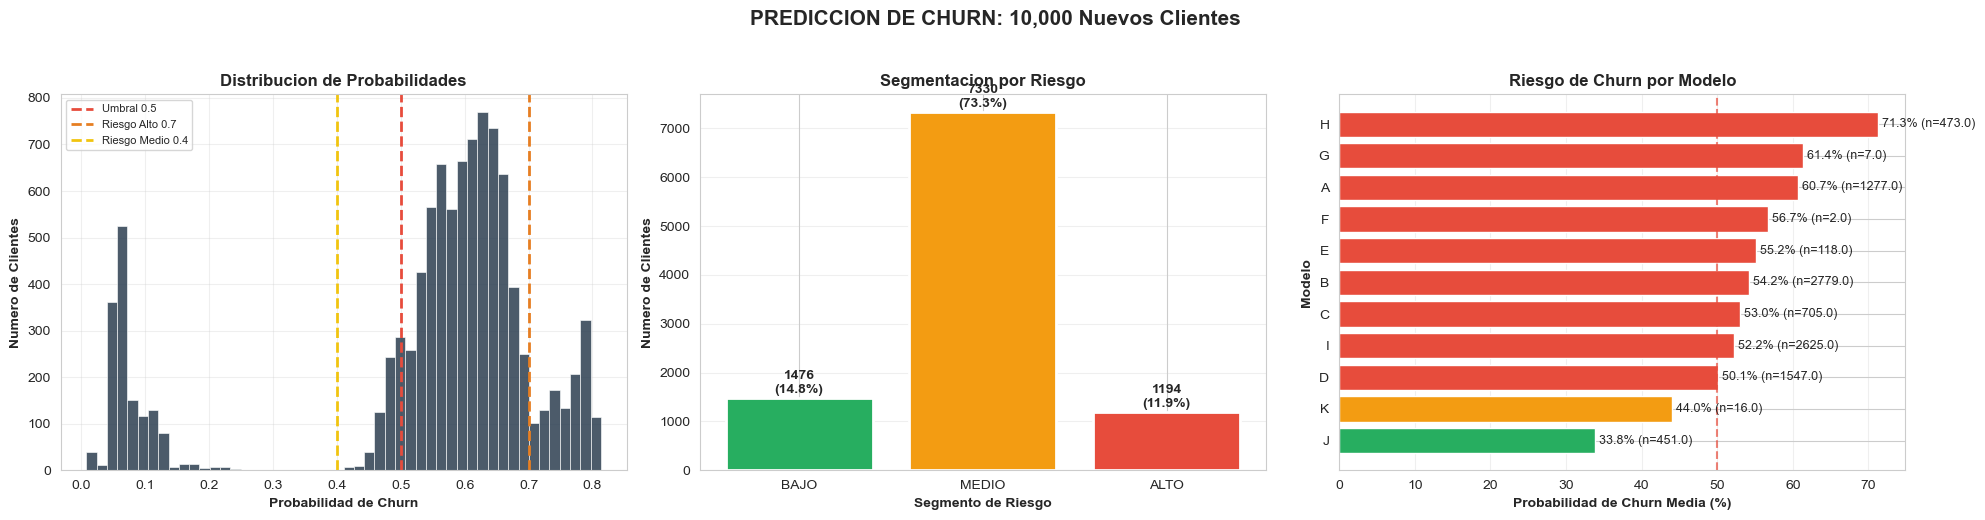

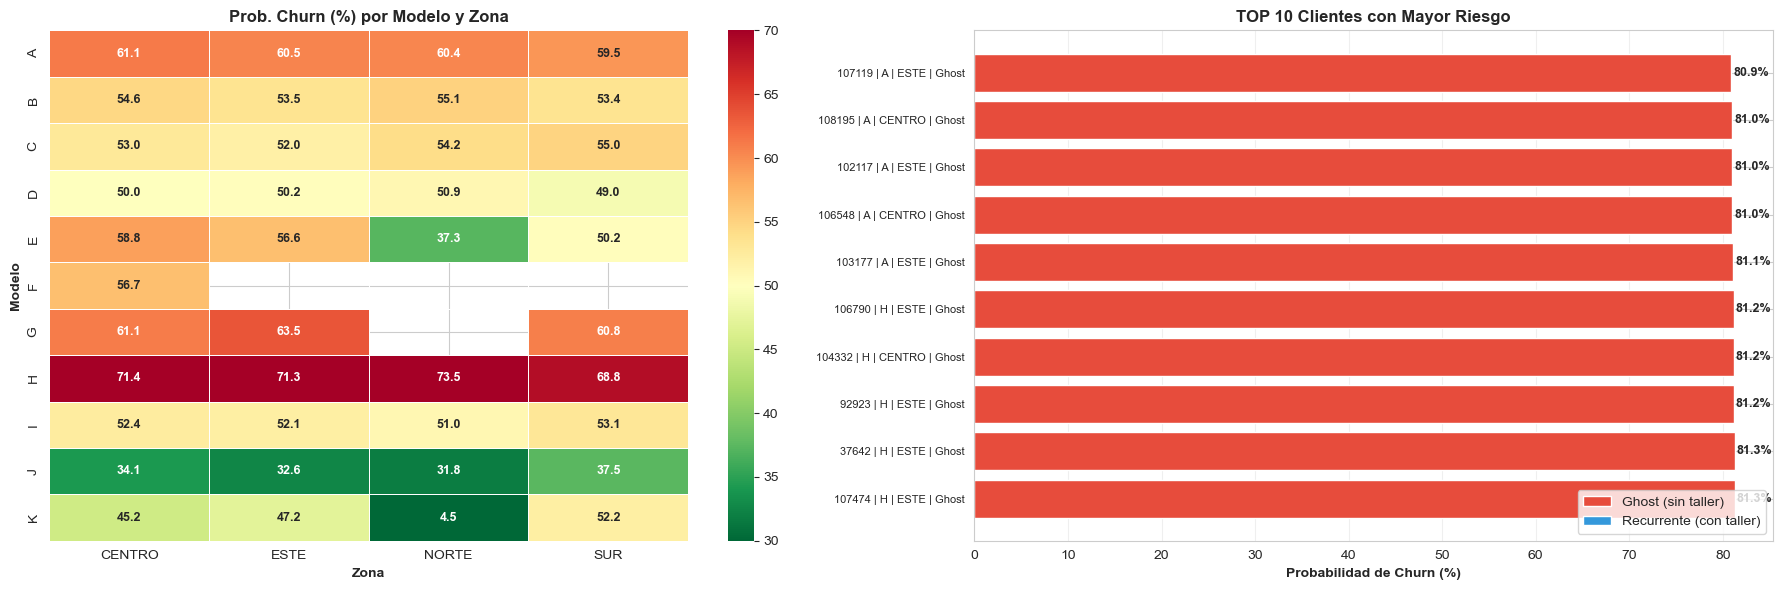


RESUMEN EJECUTIVO: PREDICCION FRESH DATA

Total clientes nuevos               10000
Riesgo ALTO (prob >= 70%)      1194 (11.9%)
Riesgo MEDIO (40-70%)          7330 (73.3%)
Riesgo BAJO (prob < 40%)       1476 (14.8%)

Modelo MENOS riesgo: J (33.8%)
Modelo MAS riesgo:   H (71.3%)

Zona MENOS riesgo:   ESTE (53.3%)
Zona MAS riesgo:     CENTRO (53.9%)

Valor total vehiculos:       235,553,275 EUR
Valor en riesgo ALTO:        29,631,087 EUR (12.6%)


In [19]:
# =================================================================
# VISUALIZACION AVANZADA: PREDICCIONES DE CHURN EN NUEVOS CLIENTES
# =================================================================
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

# =============================================
# FIGURA 1: Distribucion de Riesgo con Gradiente y Umbral
# =============================================
fig, ax = plt.subplots(figsize=(14, 6))

# Histograma base (transparente, solo para obtener los bins)
n_bins = 60
counts, bin_edges, _ = ax.hist(resultados['prob_churn'], bins=n_bins,
                                edgecolor='white', linewidth=0.5, alpha=0)

# Redibujar cada barra con gradiente verde → amarillo → rojo
ax.cla()
for i in range(len(counts)):
    center = (bin_edges[i] + bin_edges[i+1]) / 2
    # Gradiente: 0.0 = verde puro, 0.5 = amarillo, 1.0 = rojo puro
    r = min(1.0, center * 2)
    g = min(1.0, 2.0 - center * 2)
    color = (r, g, 0.15)
    ax.bar(bin_edges[i], counts[i], width=bin_edges[i+1]-bin_edges[i],
           color=color, edgecolor='white', linewidth=0.4, align='edge')

# Linea umbral 0.7
ax.axvline(x=0.7, color='#c0392b', linewidth=2.5, linestyle='--', zorder=5)
pct_above_07 = (resultados['prob_churn'] >= 0.7).mean() * 100
ax.text(0.72, ax.get_ylim()[1] * 0.92,
        f'{pct_above_07:.1f}% superan\numbral 0.7',
        fontsize=12, fontweight='bold', color='#c0392b',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#c0392b', alpha=0.9))

# Linea umbral 0.4
ax.axvline(x=0.4, color='#f39c12', linewidth=2, linestyle='--', alpha=0.7, zorder=5)
pct_above_04 = (resultados['prob_churn'] >= 0.4).mean() * 100
ax.text(0.41, ax.get_ylim()[1] * 0.75,
        f'{pct_above_04:.1f}% superan 0.4',
        fontsize=10, color='#e67e22', fontstyle='italic')

ax.set_xlabel('Score de Churn (probabilidad)', fontsize=13, fontweight='bold')
ax.set_ylabel('Numero de Clientes', fontsize=13, fontweight='bold')
ax.set_title('Distribucion de Riesgo con Gradiente y Umbral',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlim([0, 1])
ax.grid(True, alpha=0.2, axis='y')

# Leyenda manual
legend_elements = [
    Patch(facecolor='#1e8449', label='Riesgo Bajo (<0.4)'),
    Patch(facecolor='#d4ac0d', label='Riesgo Medio (0.4-0.7)'),
    Patch(facecolor='#c0392b', label='Riesgo Alto (>0.7)'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=11,
          framealpha=0.9, edgecolor='gray')
plt.tight_layout()
plt.show()

# =============================================
# FIGURA 2: Valor Economico en Riesgo por Segmento
# =============================================
fig, ax = plt.subplots(figsize=(10, 6))

pvp_por_seg = resultados.groupby('riesgo')['PVP'].sum().reindex(['BAJO', 'MEDIO', 'ALTO'])
pvp_millones = pvp_por_seg / 1_000_000

colors_seg = {'BAJO': '#27ae60', 'MEDIO': '#f39c12', 'ALTO': '#e74c3c'}
bars = ax.bar(pvp_millones.index, pvp_millones.values,
              color=[colors_seg[s] for s in pvp_millones.index],
              edgecolor='white', linewidth=2, width=0.6)

# Etiquetas sobre cada barra
for bar, seg in zip(bars, pvp_millones.index):
    val = bar.get_height()
    n_clientes = (resultados['riesgo'] == seg).sum()
    pvp_medio = resultados[resultados['riesgo'] == seg]['PVP'].mean()
    ax.text(bar.get_x() + bar.get_width()/2, val + pvp_millones.max()*0.02,
            f'{val:,.2f}M EUR\n({n_clientes:,} clientes)\nPVP medio: {pvp_medio:,.0f} EUR',
            ha='center', va='bottom', fontweight='bold', fontsize=11,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))

ax.set_xlabel('Segmento de Riesgo', fontsize=13, fontweight='bold')
ax.set_ylabel('PVP Total Acumulado (Millones EUR)', fontsize=13, fontweight='bold')
ax.set_title('Valor Economico en Riesgo por Segmento',
             fontsize=16, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, pvp_millones.max() * 1.35])
plt.tight_layout()
plt.show()

# =============================================
# FIGURA 3: Matriz Estrategica 'Valor vs. Riesgo'
# =============================================
fig, ax = plt.subplots(figsize=(14, 8))

# Umbrales para los cuadrantes
umbral_pvp = resultados['PVP'].median()
umbral_churn = 0.5

# Asignar cuadrante a cada cliente
def cuadrante(row):
    if row['PVP'] >= umbral_pvp and row['prob_churn'] >= umbral_churn:
        return 'VIPs en Peligro'
    elif row['PVP'] >= umbral_pvp and row['prob_churn'] < umbral_churn:
        return 'VIPs Seguros'
    elif row['PVP'] < umbral_pvp and row['prob_churn'] >= umbral_churn:
        return 'Bajo Valor + Alto Riesgo'
    else:
        return 'Bajo Valor + Bajo Riesgo'

resultados['cuadrante'] = resultados.apply(cuadrante, axis=1)

colores_cuad = {
    'VIPs en Peligro': '#e74c3c',
    'VIPs Seguros': '#2ecc71',
    'Bajo Valor + Alto Riesgo': '#f39c12',
    'Bajo Valor + Bajo Riesgo': '#3498db'
}

# Scatter por cuadrante
for cuad, color in colores_cuad.items():
    mask = resultados['cuadrante'] == cuad
    n = mask.sum()
    ax.scatter(resultados.loc[mask, 'PVP'],
               resultados.loc[mask, 'prob_churn'],
               c=color, alpha=0.4, s=15, label=f'{cuad} ({n:,})', edgecolors='none')

# Lineas de cuadrante
ax.axhline(y=umbral_churn, color='#2c3e50', linewidth=1.5, linestyle='--', alpha=0.6)
ax.axvline(x=umbral_pvp, color='#2c3e50', linewidth=1.5, linestyle='--', alpha=0.6)

# Etiquetas en cuadrantes
y_max = resultados['prob_churn'].max()
x_max = resultados['PVP'].max()
x_min = resultados['PVP'].min()

n_vip_peligro = (resultados['cuadrante'] == 'VIPs en Peligro').sum()
pvp_vip_peligro = resultados[resultados['cuadrante'] == 'VIPs en Peligro']['PVP'].sum() / 1_000_000

ax.text(umbral_pvp + (x_max - umbral_pvp)*0.5, umbral_churn + (y_max - umbral_churn)*0.85,
        f'VIPs EN PELIGRO\n{n_vip_peligro:,} clientes\n{pvp_vip_peligro:,.1f}M EUR',
        ha='center', va='center', fontsize=12, fontweight='bold', color='#c0392b',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#fadbd8', edgecolor='#e74c3c', alpha=0.85))

n_vip_seguro = (resultados['cuadrante'] == 'VIPs Seguros').sum()
ax.text(umbral_pvp + (x_max - umbral_pvp)*0.5, umbral_churn * 0.15,
        f'VIPs SEGUROS\n{n_vip_seguro:,} clientes',
        ha='center', va='center', fontsize=11, fontweight='bold', color='#1e8449',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#d5f5e3', edgecolor='#27ae60', alpha=0.85))

ax.set_xlabel('PVP del Vehiculo (EUR)', fontsize=13, fontweight='bold')
ax.set_ylabel('Score de Churn (probabilidad)', fontsize=13, fontweight='bold')
ax.set_title('Matriz Estrategica: Valor vs. Riesgo',
             fontsize=16, fontweight='bold', pad=15)
ax.legend(loc='center left', fontsize=10, framealpha=0.9, edgecolor='gray',
          markerscale=3)
ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.show()

# =============================================
# FIGURA 4: Mapa de Calor Riesgo Geografico-Modelo
# =============================================
fig, ax = plt.subplots(figsize=(14, 7))

pivot_prob = resultados.pivot_table(values='prob_churn', index='Modelo',
                                     columns='ZONA', aggfunc='mean') * 100

# Ordenar por riesgo medio
pivot_prob = pivot_prob.loc[pivot_prob.mean(axis=1).sort_values(ascending=False).index]

sns.heatmap(pivot_prob, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=ax,
            linewidths=1, linecolor='white',
            annot_kws={'size': 11, 'weight': 'bold'},
            vmin=pivot_prob.values.min() - 5,
            vmax=pivot_prob.values.max() + 5,
            cbar_kws={'label': 'Probabilidad Churn (%)', 'shrink': 0.8})

# Marcar el foco critico (celda con mayor probabilidad)
max_val = pivot_prob.max().max()
max_modelo = pivot_prob.max(axis=1).idxmax()
max_zona = pivot_prob.max(axis=0).idxmax()

# Encontrar posicion exacta del maximo
for i, modelo in enumerate(pivot_prob.index):
    for j, zona in enumerate(pivot_prob.columns):
        if pivot_prob.loc[modelo, zona] == max_val:
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False,
                         edgecolor='#c0392b', linewidth=3, zorder=10))
            max_modelo = modelo
            max_zona = zona

ax.set_xlabel('Zona Geografica', fontsize=13, fontweight='bold')
ax.set_ylabel('Modelo de Vehiculo', fontsize=13, fontweight='bold')
ax.set_title('Mapa de Calor: Riesgo de Churn por Modelo y Zona\n(recuadro rojo = foco critico)',
             fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# =============================================
# RESUMEN EJECUTIVO
# =============================================
print('')
print('='*70)
print('RESUMEN EJECUTIVO: PREDICCION EN NUEVOS CLIENTES')
print('='*70)

# PVP en riesgo alto
pvp_alto = resultados[resultados['riesgo'] == 'ALTO']['PVP'].sum()
pvp_total = resultados['PVP'].sum()
n_alto = (resultados['riesgo'] == 'ALTO').sum()
n_total = len(resultados)

print('')
print('VALOR ECONOMICO EN RIESGO ALTO:')
print('-'*55)
print(f'   Clientes en riesgo alto:   {n_alto:,} de {n_total:,} ({n_alto/n_total*100:.1f}%)')
print(f'   PVP total en riesgo alto:  {pvp_alto:,.0f} EUR ({pvp_alto/1_000_000:,.2f}M EUR)')
print(f'   PVP total cartera:         {pvp_total:,.0f} EUR ({pvp_total/1_000_000:,.2f}M EUR)')
print(f'   % del valor en peligro:    {pvp_alto/pvp_total*100:.1f}%')

# Foco critico modelo/zona
print('')
print('FOCO CRITICO (mayor probabilidad de fuga):')
print('-'*55)
print(f'   Modelo:  {max_modelo}')
print(f'   Zona:    {max_zona}')
print(f'   Prob. media de churn: {max_val:.1f}%')

# Top 3 combinaciones
combo = resultados.groupby(['Modelo', 'ZONA']).agg(
    prob_media=('prob_churn', 'mean'),
    n_clientes=('prob_churn', 'count'),
    pvp_total=('PVP', 'sum')
).sort_values('prob_media', ascending=False).head(3)

print('')
print('TOP 3 combinaciones Modelo/Zona con mayor riesgo:')
for i, ((modelo, zona), row) in enumerate(combo.iterrows(), 1):
    print(f'   {i}. {modelo} en {zona}: '
          f'{row["prob_media"]*100:.1f}% churn, '
          f'{row["n_clientes"]} clientes, '
          f'{row["pvp_total"]:,.0f} EUR')

# VIPs en peligro
n_vip = (resultados['cuadrante'] == 'VIPs en Peligro').sum()
pvp_vip = resultados[resultados['cuadrante'] == 'VIPs en Peligro']['PVP'].sum()
print('')
print('VIPs EN PELIGRO (alto valor + alta prob. churn):')
print('-'*55)
print(f'   Clientes:  {n_vip:,}')
print(f'   PVP total: {pvp_vip:,.0f} EUR ({pvp_vip/1_000_000:,.2f}M EUR)')
print('='*70)

## Conclusion: Prediccion sobre Nuevos Clientes

### Visualizaciones realizadas

1. **Distribucion de Riesgo con Gradiente:** El histograma con gradiente verde-rojo permite
   identificar de un vistazo la concentracion de clientes en cada nivel de riesgo. El umbral
   0.7 marca la frontera de accion comercial urgente.

2. **Valor Economico en Riesgo:** No basta con contar clientes en peligro: necesitamos saber
   cuantos millones de euros estan en juego en cada segmento para priorizar recursos.

3. **Matriz Valor vs. Riesgo:** El scatter plot de 4 cuadrantes identifica a los **VIPs en Peligro**:
   clientes con vehiculos de alto valor Y alta probabilidad de fuga. Son la prioridad absoluta
   de retencion.

4. **Mapa de Calor Geografico-Modelo:** Cruza zona y modelo para detectar **focos criticos**
   especificos donde concentrar campanas de retencion localizadas.

### Aplicacion comercial

| Segmento | Accion recomendada |
|----------|-------------------|
| **VIPs en Peligro** | Contacto personal: llamada del responsable de zona + oferta exclusiva |
| **Riesgo ALTO** | Contacto directo: llamada + oferta personalizada de primera revision gratuita |
| **Riesgo MEDIO** | Comunicacion proactiva: email/SMS con recordatorio y descuento |
| **Riesgo BAJO** | Mantenimiento estandar: comunicacion periodica, programa de fidelizacion |
| **Focos criticos (Modelo/Zona)** | Campanas localizadas en las combinaciones con mayor % churn |